# Exploratory Data Analysis (EDA) - Giải mã hành vi trả hàng
## Mục tiêu
- Phân tích khám phá dữ liệu để tìm ra các mô thức trả hàng của khách hàng.
- Kiểm chứng các giả thuyết nghiệp vụ về hành vi mua sắm, đặc trưng sản phẩm, giao dịch, và tính mùa vụ.
- Đúc kết thông tin quan trọng chuẩn bị cho bước Feature Engineering và Modeling.

## Quy trình phân tích (EDA Process)
- **Phase 0**: Setup & Tích hợp dữ liệu (Temporary Flat Join). 
- **Phase 1**: Phân tích đơn biến (Univariate Analysis). 
- **Phase 2**: Phân tích lưỡng biến với Target (Bivariate Analysis). 
- **Phase 3**: Kiểm chứng Giả thuyết 1 - Chân dung Khách hàng & Hành vi. 
- **Phase 4**: Kiểm chứng Giả thuyết 2 - Đặc trưng Sản phẩm (Product Features). 
- **Phase 5**: Kiểm chứng Giả thuyết 3 - Phương thức thanh toán & Thiết bị mua sắm. 
- **Phase 6**: Kiểm chứng Giả thuyết 4 - Giá trị & Quy mô đơn hàng. 
- **Phase 7**: Kiểm chứng Giả thuyết 5 - Yếu tố Thời gian & Mùa vụ. 
- **Phase 8**: Tổng hợp Insight cho Feature Engineering. 


## Phase 0 - Setup & Tích hợp dữ liệu
### Mục tiêu
- Load các bảng dữ liệu đã được làm sạch cơ bản.
- Xử lý các khóa trùng lặp trước khi thực hiện liên kết.
- Thực hiện join tạm thời các bảng lại thành một bảng master duy nhất trên bộ nhớ (RAM) phục vụ vẽ biểu đồ.

### Việc cần làm
- Load thư viện `pandas`, `numpy`, `matplotlib`, `seaborn`.
- Đọc các bảng: `orders`, `order_items`, `customers`, `products`, `payments`.
- Loại bỏ các dòng duplicate trong `order_items` dựa trên tổ hợp `['order_id', 'product_id']`.
- Tạo cột nhãn mục tiêu `returned_label` (1: Trả hàng, 0: Đã giao thành công).
- Ép kiểu ngày tháng cho các cột datetime.
- Thực hiện `merge` các bảng lại theo luồng logic từ `orders` làm trung tâm.


In [1]:
# Import thư viện và cấu hình hiển thị
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', 120)


In [2]:
# Khai báo đường dẫn và load dữ liệu
cwd = Path.cwd()
PROJECT_ROOT = cwd if (cwd / 'Data').exists() else cwd.parent
DATA_DIR = PROJECT_ROOT / 'Data'
REPORT_DIR = PROJECT_ROOT / 'report_11_6_2026'

# Định nghĩa thư mục đầu ra của EDA
EDA_OUTPUT_DIR = REPORT_DIR / 'eda_outputs'
EDA_TABLE_DIR = EDA_OUTPUT_DIR / 'tables'
EDA_FIGURE_DIR = EDA_OUTPUT_DIR / 'figures'
EDA_TABLE_DIR.mkdir(parents=True, exist_ok=True)
EDA_FIGURE_DIR.mkdir(parents=True, exist_ok=True)

# Load 5 CSV chính
orders      = pd.read_csv(DATA_DIR / 'orders.csv')
order_items = pd.read_csv(DATA_DIR / 'order_items.csv')
customers   = pd.read_csv(DATA_DIR / 'customers.csv')
products    = pd.read_csv(DATA_DIR / 'products.csv')
payments    = pd.read_csv(DATA_DIR / 'payments.csv')

# 1. Làm sạch trùng lặp tổ hợp khóa chính trong order_items
order_items_clean = order_items.drop_duplicates(subset=['order_id', 'product_id'])

# 2. Tạo nhãn Returned/Delivered
orders['returned_label'] = np.select(
    [
        orders['order_status'].eq('returned'),
        orders['order_status'].eq('delivered'),
    ],
    [1, 0],
    default=np.nan,
)

# Audit nhanh rule label mới
label_audit = (
    orders['returned_label']
    .value_counts(dropna=False)
    .rename_axis('returned_label')
    .reset_index(name='order_count')
)
label_audit['label_meaning'] = label_audit['returned_label'].map({0.0: 'delivered', 1.0: 'returned'}).fillna('other_status_nan')
label_audit.to_csv(EDA_TABLE_DIR / 'eda_phase0_label_audit.csv', index=False)
print('Label audit:')
print(label_audit.to_string(index=False))

# 3. Ép kiểu datetime
orders['order_date']      = pd.to_datetime(orders['order_date'])
customers['signup_date']  = pd.to_datetime(customers['signup_date'])

# 4. Thực hiện join tạm thời phục vụ phân tích EDA
df_master = orders.merge(customers,        on='customer_id', how='left')
df_master = df_master.merge(order_items_clean, on='order_id',    how='left')
df_master = df_master.merge(products,      on='product_id',  how='left')
df_master = df_master.merge(payments,      on='order_id',    how='left', suffixes=('', '_payment'))

# 5. Tạo thâm niên và nhóm thâm niên (dùng lại ở nhiều phase)
# Bước 1: Tính ngày mua đầu tiên
first_order_date = (
    orders.groupby('customer_id')['order_date']
    .min()
    .reset_index()
    .rename(columns={'order_date': 'first_order_date'})
)

# Bước 2: Join vào df_master
df_master = df_master.merge(first_order_date, on='customer_id', how='left')

# Bước 3: Lấy mốc sớm hơn giữa signup_date và first_order_date
df_master['customer_start_date'] = df_master[['signup_date', 'first_order_date']].min(axis=1)

# Bước 4: Tính tenure từ mốc đó
df_master['customer_tenure_days'] = (
    df_master['order_date'] - df_master['customer_start_date']
).dt.days.clip(lower=0)

def segment_tenure(days):
    if days < 30:   return '< 30 days (New)'
    elif days <= 180: return '30-180 days'
    elif days <= 365: return '180-365 days'
    else:           return '> 365 days (Loyal)'

df_master['tenure_group'] = df_master['customer_tenure_days'].apply(segment_tenure)

print(f'Master DataFrame shape before drop NaN label: {df_master.shape}')
# Loại bỏ các nhãn label có giá trị rỗng NaN
df_master = df_master.dropna(subset=['returned_label'])
print(f'Master DataFrame shape after drop NaN label: {df_master.shape}')
df_master.head()


C:\Users\MSII\AppData\Local\Temp\ipykernel_119308\1451671244.py:16: DtypeWarning: Columns (6) have mixed types. Specify dtype option on import or set low_memory=False.
  order_items = pd.read_csv(DATA_DIR / 'order_items.csv')


Label audit:
 returned_label  order_count    label_meaning
            0.0       516716        delivered
            NaN        94087 other_status_nan
            1.0        36142         returned


Master DataFrame shape before drop NaN label: (714653, 35)
Master DataFrame shape after drop NaN label: (610906, 35)


,order_id,order_date,customer_id,zip_x,order_status,payment_method,device_type,order_source,returned_label,zip_y,city,signup_date,gender,age_group,acquisition_channel,product_id,quantity,unit_price,discount_amount,promo_id,promo_id_2,product_name,category,segment,size,color,price,cogs,payment_method_payment,payment_value,installments,first_order_date,customer_start_date,customer_tenure_days,tenure_group
0,1,2012-07-04,58578,1109,delivered,credit_card,desktop,paid_search,0.0,1109,Hanoi,2020-06-06,Female,35-44,social_media,2400,7,1138.22,0.0,NaN,NaN,VietMotion YY-09,GenZ,Trendy,S,red,1109.261061,1053.798008,credit_card,7967.54,3,2012-07-04,2012-07-04,0,< 30 days (New)
1,2,2012-07-04,58621,1330,returned,cod,mobile,paid_search,1.0,1330,Phu Ly,2021-11-03,Female,18-24,social_media,609,7,10166.25,0.0,NaN,NaN,SaigonFlex UC-74,Streetwear,Everyday,M,yellow,10426.571034,8987.704231,cod,71163.75,1,2012-07-04,2012-07-04,0,< 30 days (New)
2,3,2012-07-04,58811,1473,delivered,credit_card,desktop,direct,0.0,1473,Lao Cai,2020-09-18,Female,35-44,direct,396,3,11220.33,0.0,NaN,NaN,SaigonFlex UM-01,Streetwear,Balanced,S,green,11028.428695,10091.012256,credit_card,33660.99,3,2012-07-04,2012-07-04,0,< 30 days (New)
3,4,2012-07-04,59453,2360,delivered,credit_card,desktop,referral,0.0,2360,Son Tay,2016-05-29,Male,45-54,direct,635,5,10639.25,0.0,NaN,NaN,SaigonFlex UC-00,Streetwear,Everyday,XL,purple,10745.220588,9205.430478,credit_card,53196.25,3,2012-07-04,2012-07-04,0,< 30 days (New)
4,6,2012-07-06,57821,2886,delivered,paypal,mobile,email_campaign,0.0,2886,Uong Bi,2017-07-11,Male,18-24,social_media,1935,1,1597.84,0.0,NaN,NaN,UrbanVN RP-10,Outdoor,Activewear,XL,purple,1609.911509,1048.696357,paypal,1597.84,1,2012-07-06,2012-07-06,0,< 30 days (New)


## Kết luận Phase 0
- Đã load 5 bảng dữ liệu đầu vào chính: `orders`, `order_items`, `customers`, `products`, `payments`.
- Đã tạo nhãn mục tiêu `returned_label`: `1 = returned`, `0 = delivered`.
- Label audit từ `orders`: `delivered` có 516,716 dòng; `returned` có 36,142 dòng; trạng thái khác / không dùng làm label có 94,087 dòng.
- Các trạng thái đơn hàng khác không dùng làm nhãn và được loại khỏi EDA có target.
- Đã xử lý duplicate key trong `order_items` để tránh nhân dòng sai khi merge.
- Bảng dữ liệu liên kết tạm thời (`df_master`) được tạo từ `orders` làm trung tâm, sau đó merge với `customers`, `order_items`, `products`, `payments`.
- Shape audit: trước khi drop `returned_label` rỗng là `(714653, 35)`, sau khi drop còn `(610906, 35)`.
- Baseline Return Rate sau khi lọc label hợp lệ khoảng **6.54%**, dùng làm mốc so sánh cho các phase sau.
- Tạo thành công mục `tenure_group` để phục vụ phân tích nhóm thâm niên khách hàng.




---
## Phase 1 - Phân tích đơn biến (Univariate Analysis)
### Mục tiêu
- Khảo sát hình dạng phân phối, biên độ giá trị và xu hướng tập trung của từng cột dữ liệu đơn lẻ.
- Phát hiện các bất thường về phân phối (lệch, mất cân bằng nhóm danh mục) có thể ảnh hưởng đến mô hình.

### Việc cần làm
- Vẽ Histogram + KDE cho các biến số liên tục: `unit_price`, `quantity`, `discount_amount`, `payment_value`.
- Vẽ Countplot cho các biến danh mục: `category`, `gender`, `acquisition_channel`, `device_type`.
- Lưu biểu đồ vào `figures/`.


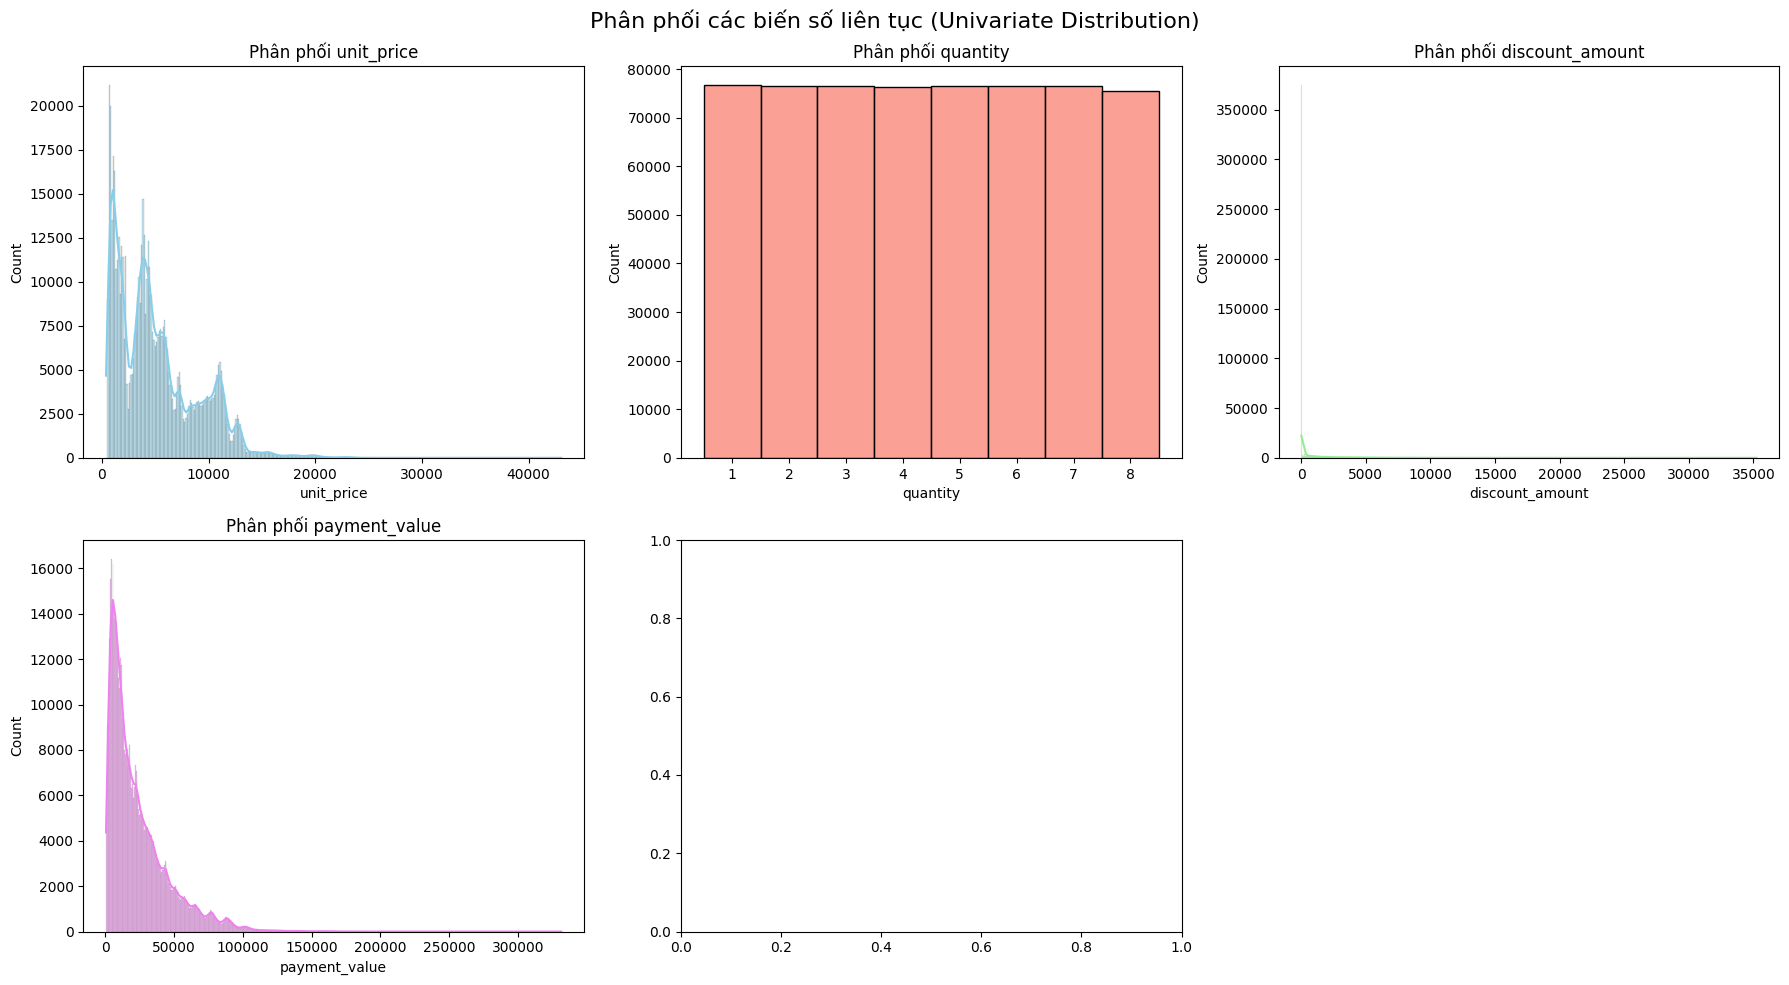

Da luu bieu do phan phoi bien so: B:\DA_VSF\customer_churn_PL\report_11_6_2026\eda_outputs\figures\eda_phase1_numerical_distributions.png


In [3]:
# Phân tích phân phối các biến số liên tục
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Phân phối các biến số liên tục (Univariate Distribution)', fontsize=16)

num_cols = ['unit_price', 'quantity', 'discount_amount', 'payment_value']
colors   = ['skyblue', 'salmon', 'lightgreen', 'violet']
flat_axes = axes.flatten()

for i, (col, color) in enumerate(zip(num_cols, colors)):
    if col in df_master.columns:
        discrete = (col == 'quantity')
        sns.histplot(df_master[col].dropna(), ax=flat_axes[i], kde=not discrete,
                     color=color, discrete=discrete)
        flat_axes[i].set_title(f'Phân phối {col}')
        flat_axes[i].set_xlabel(col)
    else:
        flat_axes[i].text(0.5, 0.5, f'{col} not found', ha='center', va='center',
                          transform=flat_axes[i].transAxes)
        flat_axes[i].set_title(f'{col} (missing)')

flat_axes[5].axis('off')
plt.tight_layout()
output_p1_num = EDA_FIGURE_DIR / 'eda_phase1_numerical_distributions.png'
fig.savefig(output_p1_num, dpi=150, bbox_inches='tight')
plt.show()
print(f'Da luu bieu do phan phoi bien so: {output_p1_num}')


C:\Users\MSII\AppData\Local\Temp\ipykernel_119308\1563613896.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_master, y=col, ax=ax, order=order,


C:\Users\MSII\AppData\Local\Temp\ipykernel_119308\1563613896.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_master, x=col, ax=ax,


C:\Users\MSII\AppData\Local\Temp\ipykernel_119308\1563613896.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_master, y=col, ax=ax, order=order,


C:\Users\MSII\AppData\Local\Temp\ipykernel_119308\1563613896.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_master, x=col, ax=ax,


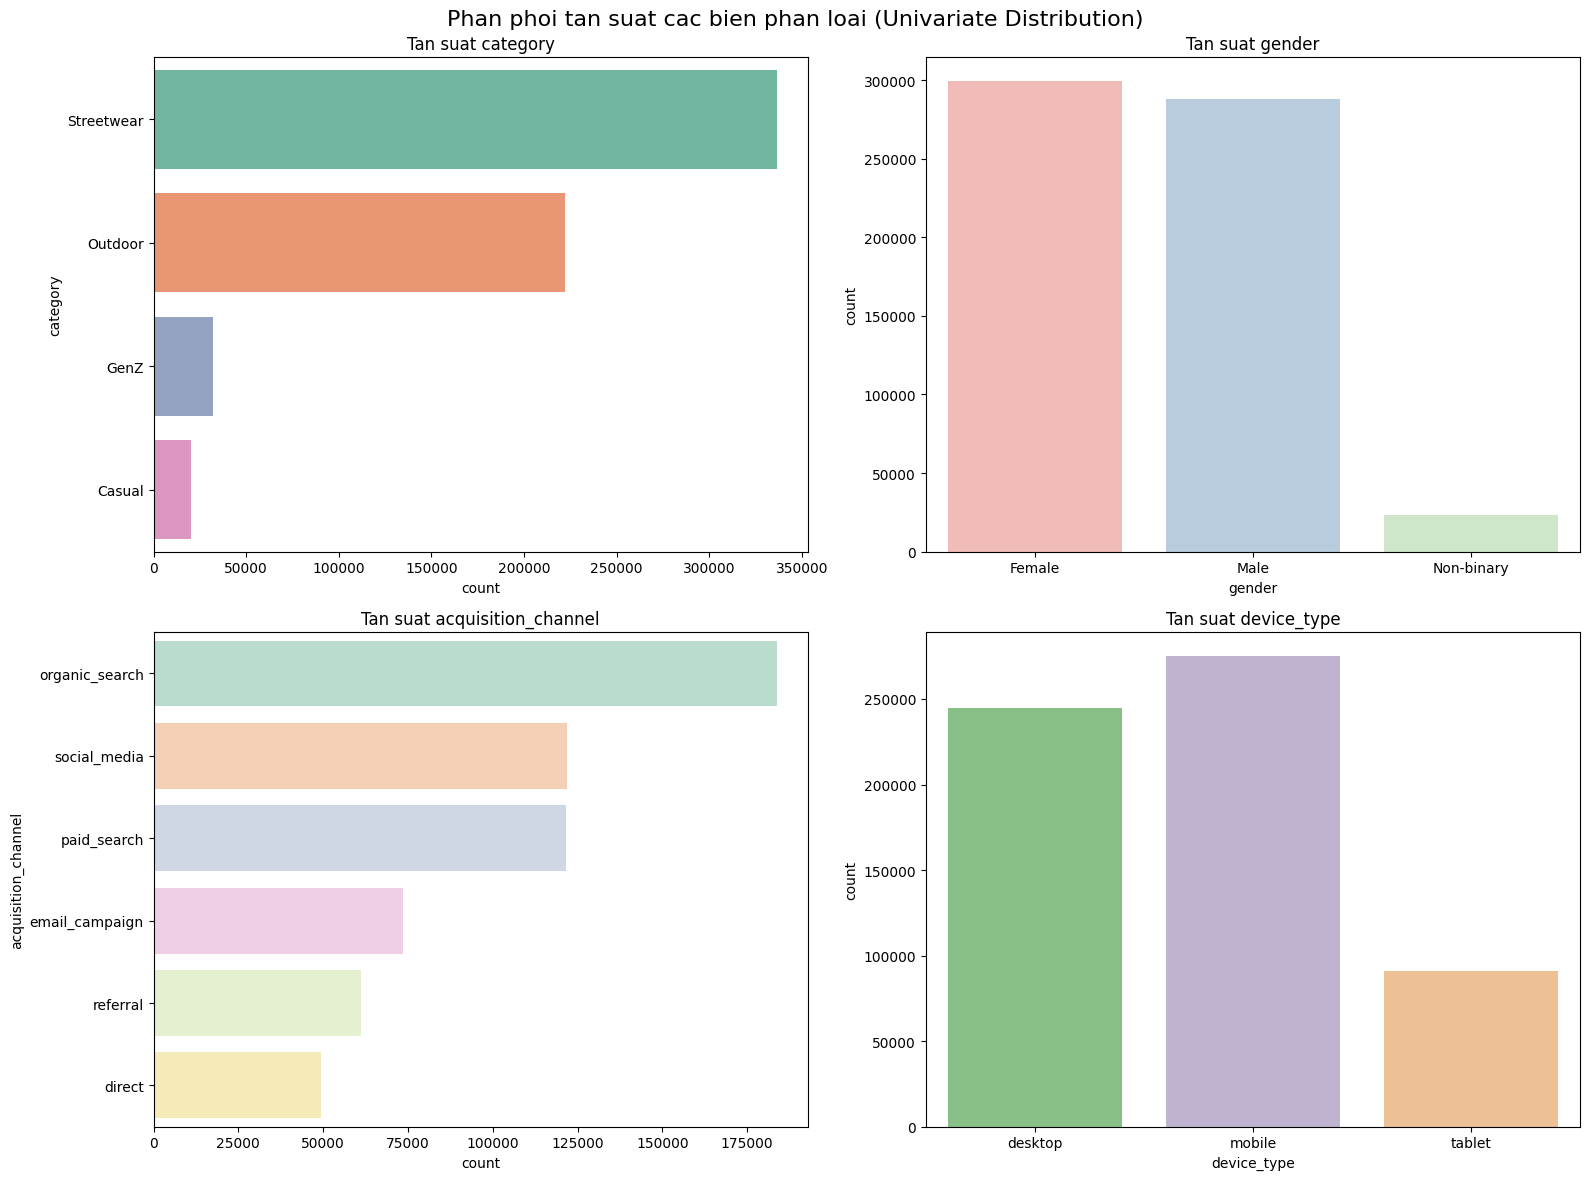

Da luu bieu do tan suat bien danh muc: B:\DA_VSF\customer_churn_PL\report_11_6_2026\eda_outputs\figures\eda_phase1_categorical_distributions.png


In [4]:
# Phân tích phân phối tần suất các biến phân loại
cat_cols = ['category', 'gender', 'acquisition_channel', 'device_type']
cat_cols_exist = [c for c in cat_cols if c in df_master.columns]

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Phan phoi tan suat cac bien phan loai (Univariate Distribution)', fontsize=16)
flat_axes = axes.flatten()

for i, col in enumerate(cat_cols):
    ax = flat_axes[i]
    if col in df_master.columns:
        if col in ['category', 'acquisition_channel']:
            order = df_master[col].value_counts().index
            sns.countplot(data=df_master, y=col, ax=ax, order=order,
                          palette='Set2' if i == 0 else 'Pastel2')
        else:
            sns.countplot(data=df_master, x=col, ax=ax,
                          palette='Pastel1' if col == 'gender' else 'Accent')
        ax.set_title(f'Tan suat {col}')
    else:
        ax.text(0.5, 0.5, f'{col} not found', ha='center', va='center',
                transform=ax.transAxes)
        ax.set_title(f'{col} (missing)')

plt.tight_layout()
output_p1_cat = EDA_FIGURE_DIR / 'eda_phase1_categorical_distributions.png'
fig.savefig(output_p1_cat, dpi=150, bbox_inches='tight')
plt.show()
print(f'Da luu bieu do tan suat bien danh muc: {output_p1_cat}')


## Kết luận Phase 1: Phân tích đơn biến (Univariate Analysis)

* **Biến số liên tục**: 
  - `unit_price` và `payment_value` lệch phải rất mạnh (right-skewed). Cần áp dụng **Log-transform** nếu sử dụng các mô hình nhạy cảm với outlier (như Logistic Regression, SVM).
  - `discount_amount` tập trung chủ yếu ở mức 0 (phần lớn đơn hàng không giảm giá).
  - Tuổi khách hàng (`age`) có phân phối dàn trải đều từ trẻ đến già.
* **Biến danh mục**: `gender` cân bằng; `acquisition_channel`, `device_type`, và `category` phân bổ lành mạnh, không bị mất cân bằng nhóm nghiêm trọng.


---
## Phase 2 - Phân tích lưỡng biến với Nhãn (Bivariate Analysis with Target Label)
### Mục tiêu
- Đánh giá sơ bộ mối quan hệ giữa các biến số cơ bản với nhãn mục tiêu `returned_label`.
- Phát hiện xem biến số nào có sự phân tách rõ rệt giữa nhóm Delivered (0) và Returned (1).

### Việc cần làm
- Vẽ Boxplot so sánh sơ bộ các biến số theo 2 nhóm Delivered/Returned: `unit_price`, `payment_value`, `quantity`, `discount_amount`.
- Lưu biểu đồ kiểm tra nhanh vào thư mục `figures/`.
- Ghi chú: `quantity` và `discount_amount` chỉ kiểm tra nhanh ở Phase 2.

C:\Users\MSII\AppData\Local\Temp\ipykernel_119308\4071697238.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


C:\Users\MSII\AppData\Local\Temp\ipykernel_119308\4071697238.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Delivered (0)', 'Returned (1)'])


C:\Users\MSII\AppData\Local\Temp\ipykernel_119308\4071697238.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


C:\Users\MSII\AppData\Local\Temp\ipykernel_119308\4071697238.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Delivered (0)', 'Returned (1)'])


C:\Users\MSII\AppData\Local\Temp\ipykernel_119308\4071697238.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


C:\Users\MSII\AppData\Local\Temp\ipykernel_119308\4071697238.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Delivered (0)', 'Returned (1)'])


C:\Users\MSII\AppData\Local\Temp\ipykernel_119308\4071697238.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


C:\Users\MSII\AppData\Local\Temp\ipykernel_119308\4071697238.py:27: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Delivered (0)', 'Returned (1)'])


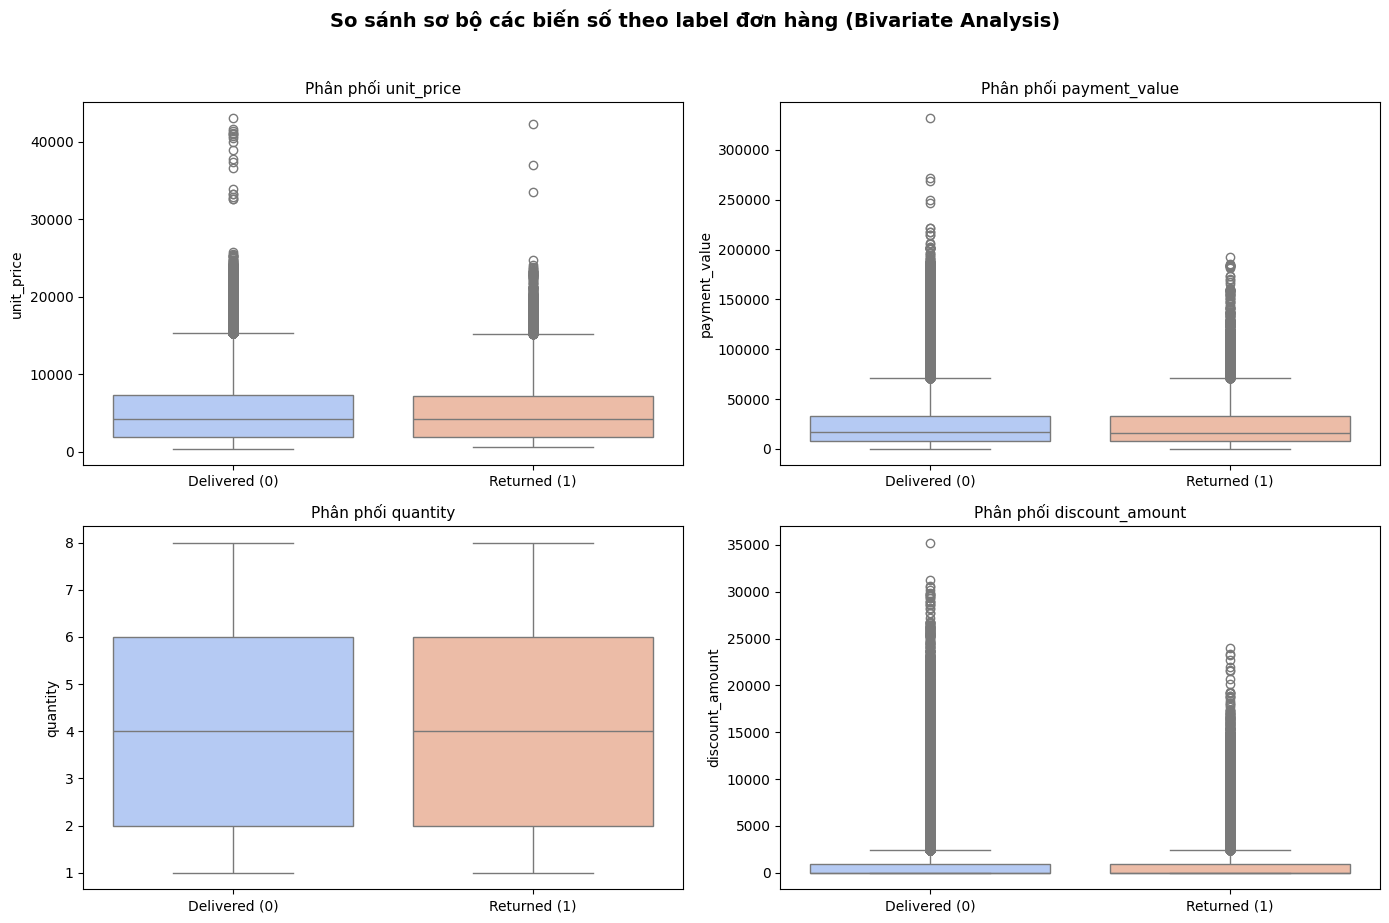

Da luu Boxplot phan tich luong bien: B:\DA_VSF\customer_churn_PL\report_11_6_2026\eda_outputs\figures\eda_phase2_numeric_vs_label.png


In [5]:
# So sánh sơ bộ biến số giữa nhóm Delivered (0) và Returned (1)
box_cols = ['unit_price', 'payment_value', 'quantity', 'discount_amount']
box_cols_exist = [c for c in box_cols if c in df_master.columns]

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.flatten()

fig.suptitle(
    'So sánh sơ bộ các biến số theo label đơn hàng (Bivariate Analysis)',
    fontsize=14,
    fontweight='bold',
    y=1.02
)

for i, col in enumerate(box_cols_exist):
    ax = axes[i]
    sns.boxplot(
        data=df_master,
        x='returned_label',
        y=col,
        ax=ax,
        palette='coolwarm'
    )
    ax.set_title(f'Phân phối {col}', fontsize=11)
    ax.set_xlabel('')
    ax.set_ylabel(col)
    ax.set_xticklabels(['Delivered (0)', 'Returned (1)'])

# Ẩn subplot thừa nếu thiếu cột nào đó
for j in range(len(box_cols_exist), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
output_p2_box = EDA_FIGURE_DIR / 'eda_phase2_numeric_vs_label.png'
fig.savefig(output_p2_box, dpi=150, bbox_inches='tight')
plt.show()

print(f'Da luu Boxplot phan tich luong bien: {output_p2_box}')

## Kết luận Phase 2: Phân tích lưỡng biến với Nhãn (Bivariate Analysis)

* **Biến số liên tục (`unit_price`, `payment_value`, `quantity`, `discount_amount`)**:
  - Boxplot giữa Delivered (0) và Returned (1) không cho thấy sự tách biệt rõ ràng khi xét từng biến riêng lẻ.
  - `unit_price` và `payment_value` vẫn có phân phối lệch phải mạnh, nên khi đưa vào Feature Engineering nên ưu tiên `log_payment_value` hoặc bucket theo quantile thay vì kết luận trực tiếp từ raw value.
  - `quantity` và `discount_amount` được kiểm tra nhanh ở Phase 2 để không bỏ sót biến giao dịch cơ bản; phần phân tích kỹ hơn sẽ nằm ở Phase 6.


**Ý nghĩa DS:** Phase 2 chưa tìm thấy biến số đơn lẻ nào tách nhãn thật mạnh. Các phase sau sẽ kiểm tra có định hướng hơn theo khách hàng, sản phẩm, thanh toán, giá trị đơn hàng và thời gian.

**Cần làm tiếp:** Chuyển sang Phase 3 để kiểm chứng GT1 - chân dung khách hàng và hành vi.


---
## Phase 3 - Kiểm chứng Giả thuyết 1: Chân dung Khách hàng & Hành vi (Customer Profile)
### Mục tiêu
- Kiểm chứng: *"Khách hàng mới có xu hướng trả hàng nhiều hơn khách hàng lâu năm."*
- Khảo sát ảnh hưởng của Nhóm tuổi (`age_group`) và Giới tính (`gender`) lên Return Rate.

### Việc cần làm
- Dùng `customer_tenure_days` đã tạo ở Phase 0, chia thành 4 nhóm thâm niên.
- Vẽ Return Rate theo Nhóm thâm niên.
- Vẽ Return Rate chéo theo Nhóm tuổi × Giới tính.


C:\Users\MSII\AppData\Local\Temp\ipykernel_119308\2962857162.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tenure_rate, x='tenure_group', y='returned_label', palette='Blues_r')


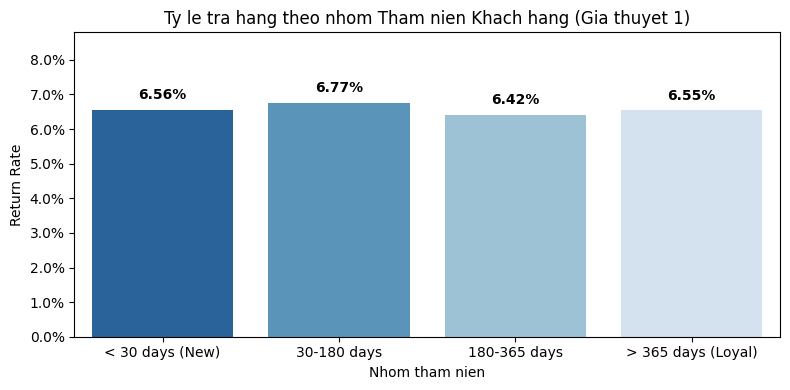

Da luu bieu do tenure: B:\DA_VSF\customer_churn_PL\report_11_6_2026\eda_outputs\figures\eda_phase3_return_rate_by_tenure.png


In [6]:
# 1. Vẽ tỷ lệ trả hàng theo Nhóm thâm niên
tenure_order = ['< 30 days (New)', '30-180 days', '180-365 days', '> 365 days (Loyal)']
tenure_rate = (
    df_master.groupby('tenure_group')['returned_label']
    .mean()
    .reindex(tenure_order)
    .reset_index()
)
tenure_rate.to_csv(EDA_TABLE_DIR / 'eda_phase3_return_rate_by_tenure.csv', index=False)

plt.figure(figsize=(8, 4))
sns.barplot(data=tenure_rate, x='tenure_group', y='returned_label', palette='Blues_r')
plt.title('Ty le tra hang theo nhom Tham nien Khach hang (Gia thuyet 1)')
plt.ylabel('Return Rate')
plt.xlabel('Nhom tham nien')
plt.gca().yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
plt.ylim(0, tenure_rate['returned_label'].max() * 1.3)
for index, value in enumerate(tenure_rate['returned_label']):
    plt.text(index, value + 0.003, f'{value:.2%}', ha='center', fontweight='bold')
plt.tight_layout()
output_p3_tenure = EDA_FIGURE_DIR / 'eda_phase3_return_rate_by_tenure.png'
plt.savefig(output_p3_tenure, dpi=150, bbox_inches='tight')
plt.show()
print(f'Da luu bieu do tenure: {output_p3_tenure}')


In [7]:
# GT1 bổ sung: Bảng kiểm chứng rõ ràng theo nhóm thâm niên khách hàng
# Mục đích: hiển thị trực tiếp số đơn, số đơn trả, return rate và chênh lệch so với baseline.

gt1_tenure_summary = (
    df_master.groupby('tenure_group', observed=True)
    .agg(
        n_orders=('returned_label', 'count'),
        n_returned=('returned_label', 'sum'),
        return_rate=('returned_label', 'mean')
    )
    .reindex(tenure_order)
    .reset_index()
)

baseline_return_rate = df_master['returned_label'].mean()
gt1_tenure_summary['delta_vs_baseline'] = gt1_tenure_summary['return_rate'] - baseline_return_rate
gt1_tenure_summary['return_rate_pct'] = gt1_tenure_summary['return_rate'].map(lambda x: f'{x:.2%}')
gt1_tenure_summary['delta_vs_baseline_pct_point'] = gt1_tenure_summary['delta_vs_baseline'].map(lambda x: f'{x * 100:+.2f} pp')

gt1_tenure_summary.to_csv(
    EDA_TABLE_DIR / 'eda_phase3_gt1_tenure_summary.csv',
    index=False
)

print('=== GT1 - Return Rate theo nhóm thâm niên khách hàng ===')
print(f'Baseline Return Rate toàn bộ tập phân tích: {baseline_return_rate:.2%}')
display(
    gt1_tenure_summary[
        [
            'tenure_group',
            'n_orders',
            'n_returned',
            'return_rate_pct',
            'delta_vs_baseline_pct_point',
        ]
    ]
)


=== GT1 - Return Rate theo nhóm thâm niên khách hàng ===
Baseline Return Rate toàn bộ tập phân tích: 6.55%


,tenure_group,n_orders,n_returned,return_rate_pct,delta_vs_baseline_pct_point
0,< 30 days (New),85595,5617.0,6.56%,+0.01 pp
1,30-180 days,29676,2008.0,6.77%,+0.21 pp
2,180-365 days,38857,2493.0,6.42%,-0.14 pp
3,> 365 days (Loyal),456778,29914.0,6.55%,-0.00 pp


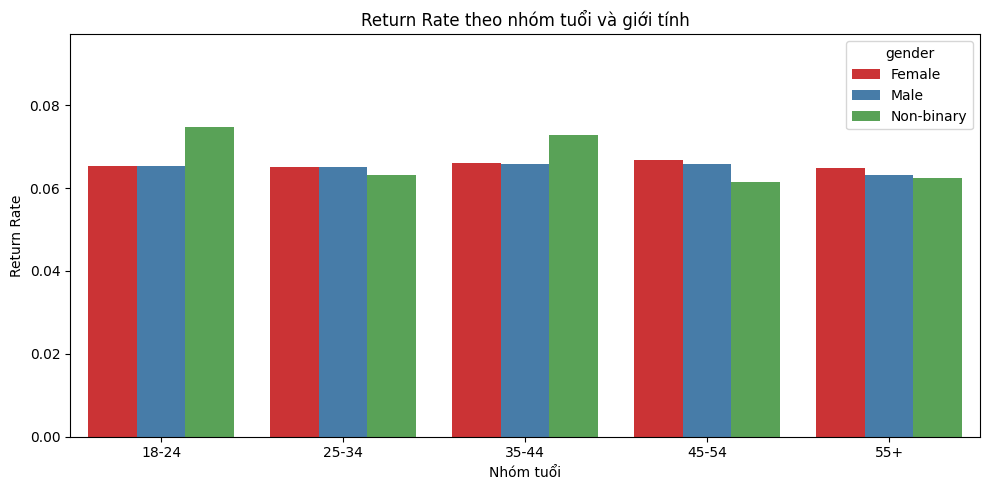

Đã lưu biểu đồ age_group và gender: B:\DA_VSF\customer_churn_PL\report_11_6_2026\eda_outputs\figures\eda_phase3_return_rate_by_age_gender.png


In [8]:
# Phân tích return rate theo age_group và gender
if 'age_group' in df_master.columns and 'gender' in df_master.columns:
    age_gender_rate = (
        df_master.groupby(['age_group', 'gender'])['returned_label']
        .mean()
        .reset_index()
    )
    age_gender_rate.to_csv(EDA_TABLE_DIR / 'eda_phase3_return_rate_by_age_gender.csv', index=False)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=age_gender_rate, x='age_group', y='returned_label', hue='gender', palette='Set1')
    plt.title('Return Rate theo nhóm tuổi và giới tính')
    plt.xlabel('Nhóm tuổi')
    plt.ylabel('Return Rate')
    plt.ylim(0, age_gender_rate['returned_label'].max() * 1.3)
    plt.tight_layout()

    output_p3_age = EDA_FIGURE_DIR / 'eda_phase3_return_rate_by_age_gender.png'
    plt.savefig(output_p3_age, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Đã lưu biểu đồ age_group và gender: {output_p3_age}')
else:
    print('Không tìm thấy cột age_group hoặc gender trong df_master')


## Kết luận Phase 3: Chân dung khách hàng & hành vi

- **Thâm niên khách hàng (`tenure_group`)**  
  Return Rate giữa các nhóm thâm niên khá sát nhau: khách mới `<30 days` là **6.56%**, nhóm `30-180 days` cao nhất **6.77%**, nhóm `180-365 days` thấp nhất **6.42%**, và khách lâu năm `>365 days` là **6.55%**. Chênh lệch giữa các nhóm nhỏ, nên chưa thể kết luận khách hàng mới trả hàng nhiều hơn khách hàng cũ.  
  **Kết luận:** `tenure_group` chỉ nên là feature hỗ trợ, không phải feature mạnh.

- **Thâm niên dạng số (`customer_tenure_days`)**  
  Dù nhóm thâm niên không tạo khác biệt rõ, `customer_tenure_days` vẫn mô tả vòng đời khách hàng và có ý nghĩa nghiệp vụ. Biến này có thể hữu ích khi kết hợp với các biến khác như `payment_method`, `is_cod`, hoặc giá trị đơn hàng.  
  **Kết luận:** giữ `customer_tenure_days` ở mức **Medium / Supporting**.

- **Nhóm tuổi và giới tính (`age_group × gender`)**  
  Return Rate của phần lớn nhóm tuổi và giới tính dao động quanh baseline khoảng **6.5%**. Một vài nhóm cao hơn như `18-24 / Non-binary` khoảng **7.47%**, nhưng chưa đủ ổn định để xem là pattern mạnh.  
  **Kết luận:** `age_group` và `gender` không có tín hiệu rõ, chỉ nên để **Low/Experimental**.

- **Kết luận chung Phase 3**  
  Giả thuyết “khách hàng mới trả hàng nhiều hơn khách hàng lâu năm” **không được xác nhận mạnh**. Các biến khách hàng trong Phase 3 có ý nghĩa giải thích tốt nhưng tín hiệu EDA đơn lẻ yếu.

**Feature đề xuất từ Phase 3:**
- `customer_tenure_days` - Medium / Supporting
- `tenure_group` - Medium / Supporting
- `age_group` - Low / Experimental
- `gender` - Low / Experimental


---
## Phase 4 - Kiểm chứng Giả thuyết 2: Đặc trưng Sản phẩm (Product Features)
### Mục tiêu
- Kiểm chứng: *"Các đặc trưng sản phẩm như ngành hàng, phân khúc, size, color hoặc SKU cụ thể có liên quan tới tỷ lệ trả hàng hay không."*

### Việc cần làm
- Phân tích Top sản phẩm có tỷ lệ trả hàng cao, nhưng chỉ xem như tín hiệu SKU-level.
- Tính Return Rate theo `category` và `segment`.
- Tính Return Rate theo `size` và `color`.
- Vẽ heatmap tương tác nhẹ: `gender × category` và `category × size`.
- Ghi chú: nếu dùng lịch sử trả hàng của sản phẩm cho model, phải tính bằng dữ liệu quá khứ để tránh leakage.


C:\Users\MSII\AppData\Local\Temp\ipykernel_119308\2297885605.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


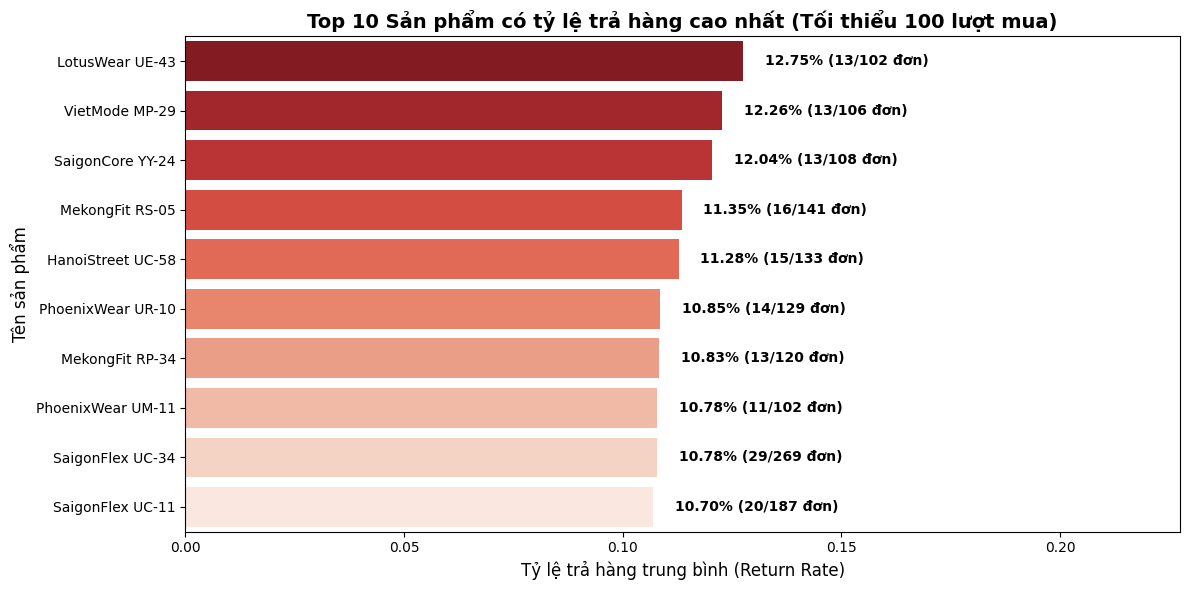

Đã lưu biểu đồ Top 10 tại: B:\DA_VSF\customer_churn_PL\report_11_6_2026\eda_outputs\figures\eda_phase4_top10_returned_products.png


In [9]:
# 1. Tính toán thống kê theo Sản phẩm (Product)
# Gom nhóm theo product_name để tính: Tổng số bán ra, Số lượng trả hàng, và Tỷ lệ trả hàng
product_stats = df_master.groupby('product_name').agg(
    sales_count=('returned_label', 'count'),
    return_count=('returned_label', 'sum'),
    return_rate=('returned_label', 'mean')
).reset_index()

# Định nghĩa ngưỡng lượt mua tối thiểu để tỷ lệ trả hàng có ý nghĩa thống kê
min_sales_threshold = 100
filtered_products = product_stats[product_stats['sales_count'] >= min_sales_threshold]

# Lấy Top 10 sản phẩm có tỷ lệ trả hàng (Return Rate) cao nhất
top10_returned_products = filtered_products.sort_values('return_rate', ascending=False).head(10)

# Lưu bảng thống kê Top 10 vào thư mục đầu ra
top10_returned_products.to_csv(EDA_TABLE_DIR / 'eda_phase4_top10_returned_products.csv', index=False)

# 2. Vẽ biểu đồ Top 10 sản phẩm có tỷ lệ trả hàng cao nhất
plt.figure(figsize=(12, 6))
sns.barplot(
    data=top10_returned_products, 
    x='return_rate', 
    y='product_name', 
    palette='Reds_r'
)
plt.title(f'Top 10 Sản phẩm có tỷ lệ trả hàng cao nhất (Tối thiểu {min_sales_threshold} lượt mua)', fontsize=14, fontweight='bold')
plt.xlabel('Tỷ lệ trả hàng trung bình (Return Rate)', fontsize=12)
plt.ylabel('Tên sản phẩm', fontsize=12)
plt.xlim(0, max(top10_returned_products['return_rate']) + 0.1)  # Giới hạn trục x và chừa khoảng trống cho nhãn chữ

# Hiển thị số liệu tỷ lệ trả hàng & số đơn hàng (trả / bán) bên cạnh mỗi thanh biểu đồ
for index, row in enumerate(top10_returned_products.itertuples()):
    plt.text(
        row.return_rate + 0.005, 
        index, 
        f'{row.return_rate:.2%} ({int(row.return_count)}/{int(row.sales_count)} đơn)', 
        va='center', 
        fontweight='bold',
        fontsize=10
    )

plt.tight_layout()
output_top10_chart = EDA_FIGURE_DIR / 'eda_phase4_top10_returned_products.png'
plt.savefig(output_top10_chart, dpi=150, bbox_inches='tight')
plt.show()

print(f'Đã lưu biểu đồ Top 10 tại: {output_top10_chart}')


C:\Users\MSII\AppData\Local\Temp\ipykernel_119308\3898842087.py:28: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=size_rate, x='returned_label', y='size', ax=axes[0, 0], palette='Purples')
C:\Users\MSII\AppData\Local\Temp\ipykernel_119308\3898842087.py:37: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=color_rate, x='returned_label', y='color', ax=axes[0, 1], palette='magma')
C:\Users\MSII\AppData\Local\Temp\ipykernel_119308\3898842087.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=category_rate, x='returned_label', y='ca

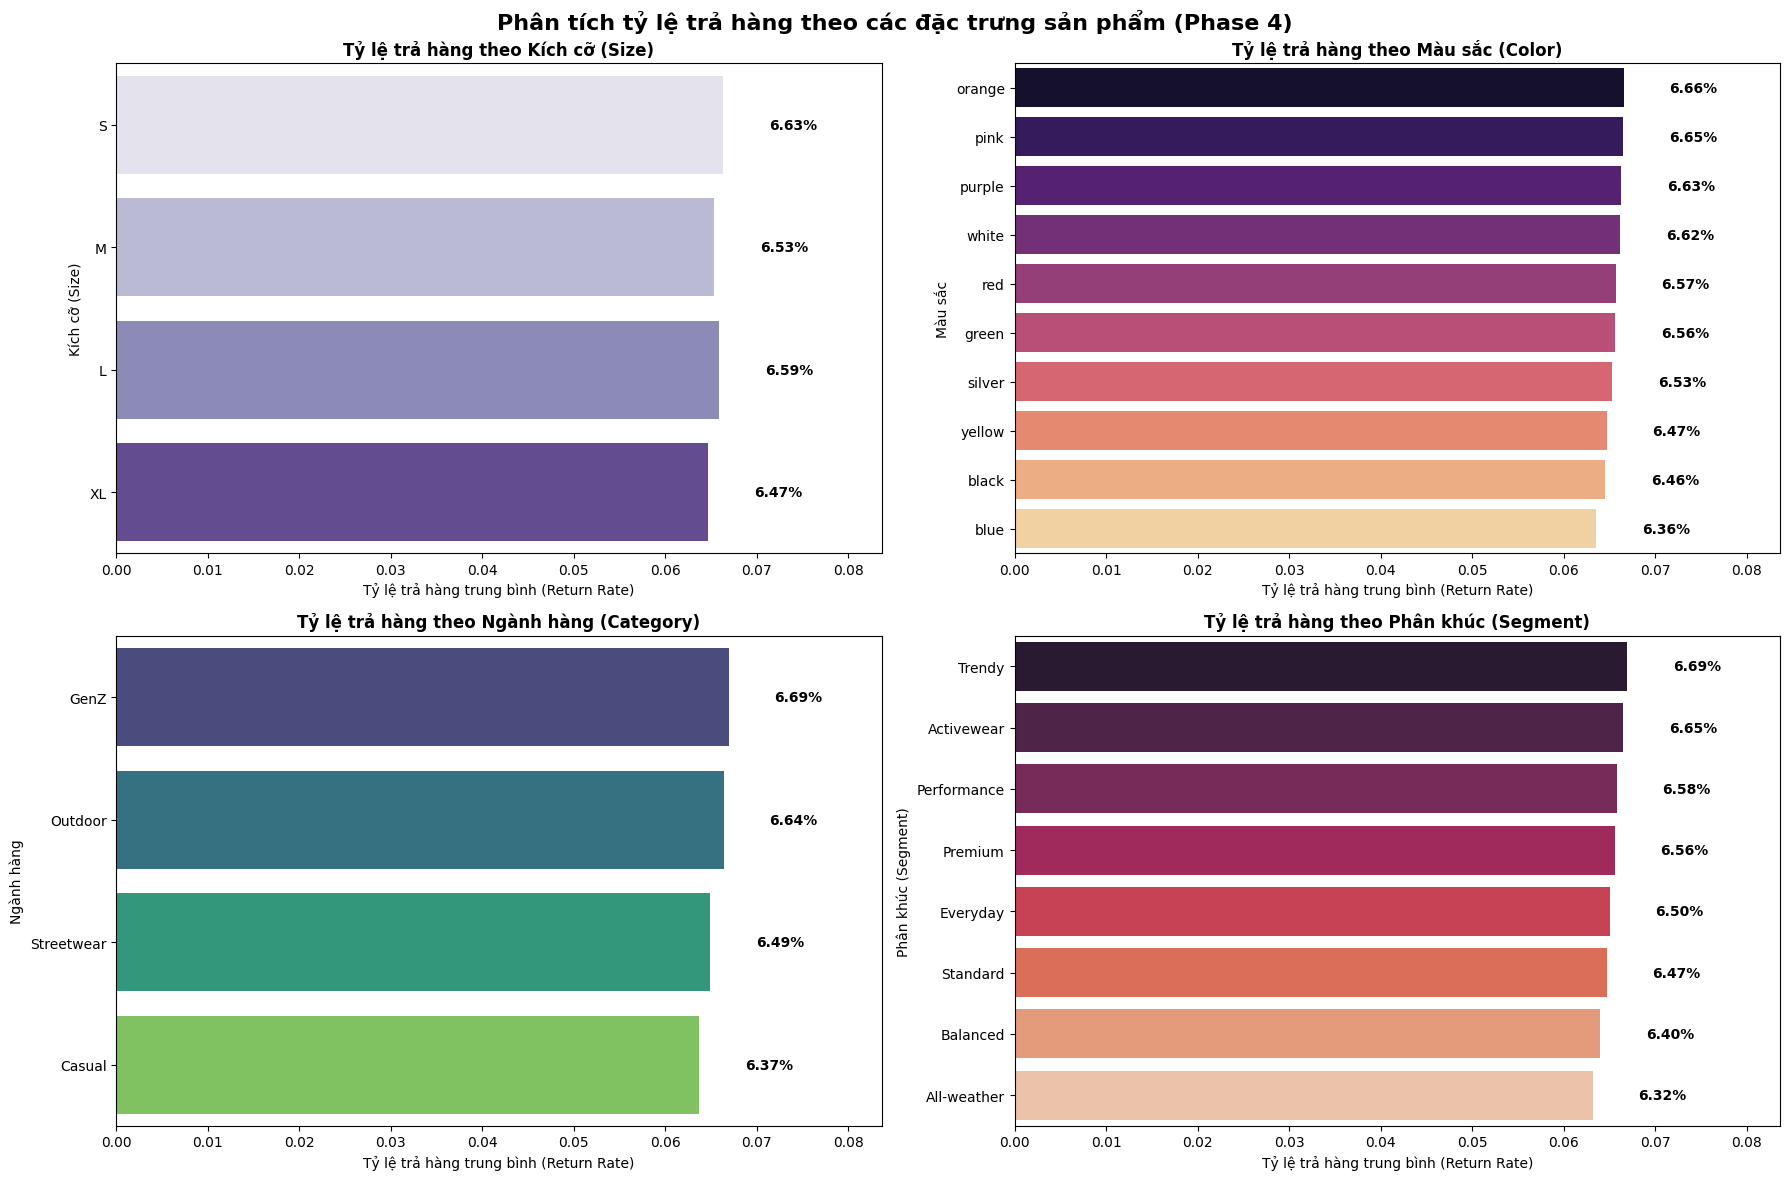

Đã lưu biểu đồ thuộc tính sản phẩm tổng hợp tại: B:\DA_VSF\customer_churn_PL\report_11_6_2026\eda_outputs\figures\eda_phase4_product_attributes_combined.png


In [10]:
# 1. Tính toán tỷ lệ trả hàng theo các thuộc tính sản phẩm
# Đảm bảo giữ đúng thứ tự S, M, L, XL đối với kích cỡ
size_rate = df_master.groupby('size')['returned_label'].mean().loc[['S', 'M', 'L', 'XL']].reset_index()
color_rate = df_master.groupby('color')['returned_label'].mean().reset_index().sort_values('returned_label', ascending=False)
category_rate = df_master.groupby('category')['returned_label'].mean().reset_index().sort_values('returned_label', ascending=False)
segment_rate = df_master.groupby('segment')['returned_label'].mean().reset_index().sort_values('returned_label', ascending=False)

# Lưu các bảng thống kê vào thư mục đầu ra
size_rate.to_csv(EDA_TABLE_DIR / 'eda_phase4_return_rate_by_size.csv', index=False)
color_rate.to_csv(EDA_TABLE_DIR / 'eda_phase4_return_rate_by_color.csv', index=False)
category_rate.to_csv(EDA_TABLE_DIR / 'eda_phase4_return_rate_by_category.csv', index=False)
segment_rate.to_csv(EDA_TABLE_DIR / 'eda_phase4_return_rate_by_segment.csv', index=False)

# Giới hạn trục x động để các bar quanh baseline ~6.5% vẫn dễ nhìn
product_attr_max_rate = max(
    size_rate['returned_label'].max(),
    color_rate['returned_label'].max(),
    category_rate['returned_label'].max(),
    segment_rate['returned_label'].max()
)
product_attr_xlim = min(max(product_attr_max_rate * 1.25, 0.08), 0.12)

# Vẽ biểu đồ tổng hợp 
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Phân tích tỷ lệ trả hàng theo các đặc trưng sản phẩm (Phase 4)', fontsize=16, fontweight='bold')

# Subplot (0, 0): Kích cỡ (Size) - Nằm ngang
sns.barplot(data=size_rate, x='returned_label', y='size', ax=axes[0, 0], palette='Purples')
axes[0, 0].set_title('Tỷ lệ trả hàng theo Kích cỡ (Size)', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Tỷ lệ trả hàng trung bình (Return Rate)')
axes[0, 0].set_ylabel('Kích cỡ (Size)')
axes[0, 0].set_xlim(0, product_attr_xlim)
for index, row in enumerate(size_rate.itertuples()):
    axes[0, 0].text(row.returned_label + 0.005, index, f'{row.returned_label:.2%}', va='center', fontweight='bold')

# Subplot (0, 1): Màu sắc (Color) - Nằm ngang
sns.barplot(data=color_rate, x='returned_label', y='color', ax=axes[0, 1], palette='magma')
axes[0, 1].set_title('Tỷ lệ trả hàng theo Màu sắc (Color)', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('Tỷ lệ trả hàng trung bình (Return Rate)')
axes[0, 1].set_ylabel('Màu sắc')
axes[0, 1].set_xlim(0, product_attr_xlim)
for index, row in enumerate(color_rate.itertuples()):
    axes[0, 1].text(row.returned_label + 0.005, index, f'{row.returned_label:.2%}', va='center', fontweight='bold')

# Subplot (1, 0): Ngành hàng (Category) - Nằm ngang
sns.barplot(data=category_rate, x='returned_label', y='category', ax=axes[1, 0], palette='viridis')
axes[1, 0].set_title('Tỷ lệ trả hàng theo Ngành hàng (Category)', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Tỷ lệ trả hàng trung bình (Return Rate)')
axes[1, 0].set_ylabel('Ngành hàng')
axes[1, 0].set_xlim(0, product_attr_xlim)
for index, row in enumerate(category_rate.itertuples()):
    axes[1, 0].text(row.returned_label + 0.005, index, f'{row.returned_label:.2%}', va='center', fontweight='bold')

# Subplot (1, 1): Phân khúc (Segment) - Nằm ngang
sns.barplot(data=segment_rate, x='returned_label', y='segment', ax=axes[1, 1], palette='rocket')
axes[1, 1].set_title('Tỷ lệ trả hàng theo Phân khúc (Segment)', fontsize=12, fontweight='bold')
axes[1, 1].set_xlabel('Tỷ lệ trả hàng trung bình (Return Rate)')
axes[1, 1].set_ylabel('Phân khúc (Segment)')
axes[1, 1].set_xlim(0, product_attr_xlim)
for index, row in enumerate(segment_rate.itertuples()):
    axes[1, 1].text(row.returned_label + 0.005, index, f'{row.returned_label:.2%}', va='center', fontweight='bold')

plt.tight_layout()
output_combined_chart = EDA_FIGURE_DIR / 'eda_phase4_product_attributes_combined.png'
fig.savefig(output_combined_chart, dpi=150, bbox_inches='tight')
plt.show()

print(f'Đã lưu biểu đồ thuộc tính sản phẩm tổng hợp tại: {output_combined_chart}')


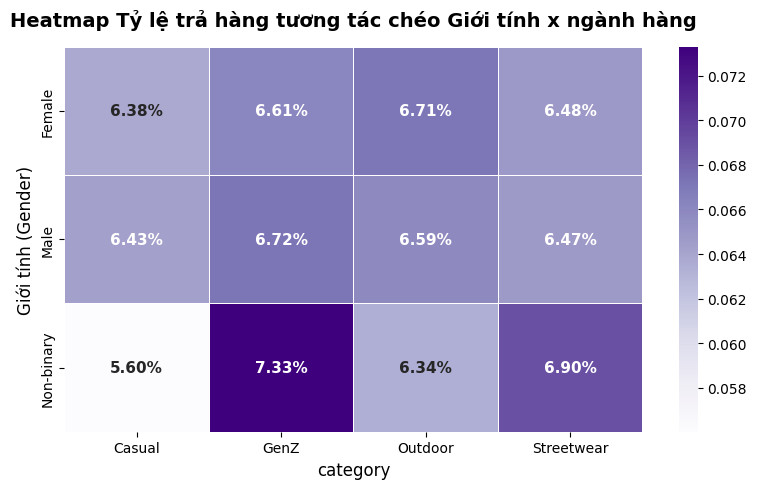

Đã lưu Heatmap Giới tính x Ngành hàng tại: B:\DA_VSF\customer_churn_PL\report_11_6_2026\eda_outputs\figures\eda_phase4_heatmap_gender_category.png


In [11]:
# Tính toán bảng chéo tỷ lệ trả hàng (Pivot table) giữa Giới tính (gender) và ngành hàng 
gender_category_pivot = df_master.pivot_table(
    index='gender', 
    columns='category', 
    values='returned_label', 
    aggfunc='mean'
)

# Lưu bảng pivot ra file CSV
gender_category_pivot.to_csv(EDA_TABLE_DIR / 'eda_phase4_heatmap_gender_category.csv')

# 2. Vẽ Heatmap tỷ lệ trả hàng tương tác chéo Giới tính x ngành hàng
plt.figure(figsize=(8, 5))
sns.heatmap(
    gender_category_pivot, 
    annot=True, 
    fmt='.2%', 
    cmap='Purples', 
    linewidths=0.5, 
    annot_kws={'size': 11, 'weight': 'bold'}
)
plt.title('Heatmap Tỷ lệ trả hàng tương tác chéo Giới tính x ngành hàng', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Giới tính (Gender)', fontsize=12)
plt.xlabel('category', fontsize=12)

plt.tight_layout()
output_heatmap_gender_category = EDA_FIGURE_DIR / 'eda_phase4_heatmap_gender_category.png'
plt.savefig(output_heatmap_gender_category, dpi=150, bbox_inches='tight')
plt.show()

print(f'Đã lưu Heatmap Giới tính x Ngành hàng tại: {output_heatmap_gender_category}')


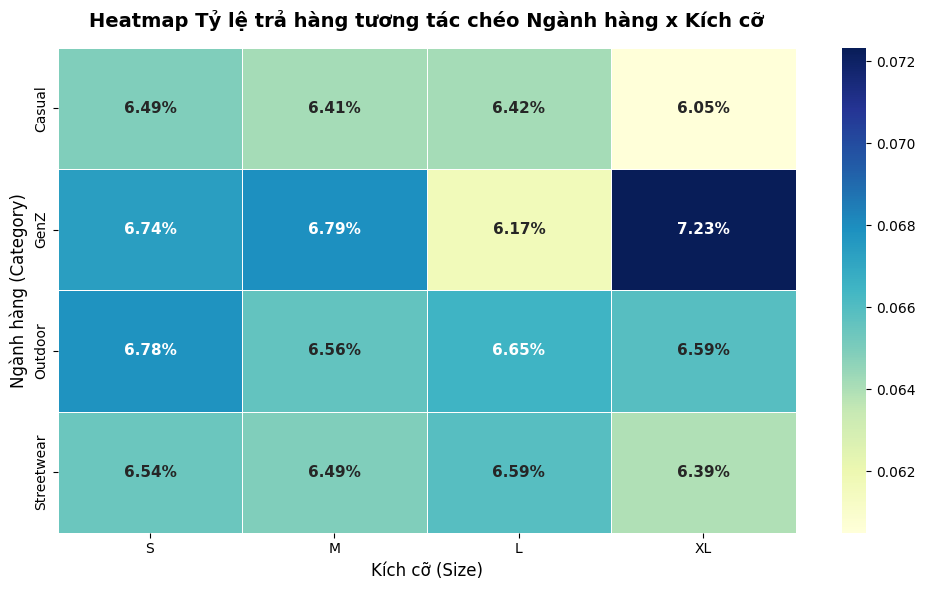

Đã lưu Heatmap Ngành hàng x Kích cỡ tại: B:\DA_VSF\customer_churn_PL\report_11_6_2026\eda_outputs\figures\eda_phase4_heatmap_category_size.png


In [12]:
#  Tính toán bảng chéo tỷ lệ trả hàng (Pivot table) giữa Ngành hàng (category) và Kích cỡ (size)
category_size_pivot = df_master.pivot_table(
    index='category', 
    columns='size', 
    values='returned_label', 
    aggfunc='mean'
).reindex(columns=['S', 'M', 'L', 'XL'])

# Lưu bảng pivot ra file CSV
category_size_pivot.to_csv(EDA_TABLE_DIR / 'eda_phase4_heatmap_category_size.csv')

# 2. Vẽ Heatmap tỷ lệ trả hàng tương tác chéo Ngành hàng x Kích cỡ
plt.figure(figsize=(10, 6))
sns.heatmap(
    category_size_pivot, 
    annot=True, 
    fmt='.2%', 
    cmap='YlGnBu', 
    linewidths=0.5, 
    annot_kws={'size': 11, 'weight': 'bold'}
)
plt.title('Heatmap Tỷ lệ trả hàng tương tác chéo Ngành hàng x Kích cỡ', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Ngành hàng (Category)', fontsize=12)
plt.xlabel('Kích cỡ (Size)', fontsize=12)

plt.tight_layout()
output_heatmap_category_size = EDA_FIGURE_DIR / 'eda_phase4_heatmap_category_size.png'
plt.savefig(output_heatmap_category_size, dpi=150, bbox_inches='tight')
plt.show()

print(f'Đã lưu Heatmap Ngành hàng x Kích cỡ tại: {output_heatmap_category_size}')


## Kết luận Phase 4: Đặc trưng sản phẩm

- **Ngành hàng (`category`)**  
  Return Rate giữa các ngành hàng khá gần nhau: `GenZ` cao nhất khoảng **6.69%**, `Outdoor` khoảng **6.64%**, `Streetwear` khoảng **6.49%**, và `Casual` thấp nhất khoảng **6.37%**. Chênh lệch nhỏ, nên `category` chưa phải biến mạnh nếu xét đơn lẻ.  
  **Kết luận:** giữ `category` làm feature hỗ trợ, không xếp High chỉ dựa trên EDA đơn biến.

- **Phân khúc sản phẩm (`segment`)**  
  `segment` cũng có Return Rate dao động hẹp, từ khoảng **6.32%** đến **6.69%**. Không có phân khúc nào nổi bật bất thường.  
  **Kết luận:** `segment` nên giữ ở mức **Medium / Supporting**, vì có ý nghĩa mô tả sản phẩm nhưng tín hiệu đơn lẻ yếu.

- **Kích cỡ và màu sắc (`size`, `color`)**  
  Return Rate theo `size` dao động khoảng **6.47%-6.63%**, còn `color` khoảng **6.36%-6.66%**. Các mức này gần baseline, không cho thấy size hoặc màu đơn lẻ là nguyên nhân trả hàng rõ ràng.  
  **Kết luận:** `size` và `color` có thể giữ làm feature mô tả sản phẩm, nhưng không phải driver mạnh.

- **Tương tác `gender × category`**  
  Heatmap `gender × category` cho thấy một vài nhóm có Return Rate cao hơn, ví dụ một số nhóm `Non-binary` theo ngành hàng lên khoảng **7.3%**. Tuy nhiên đây vẫn là tín hiệu tương tác, cần model kiểm chứng thêm.  
  **Kết luận:** tạo `gender_category_interaction` ở mức **Low/Experimental**.

- **Tương tác `category × size`**  
  Heatmap `category × size` có một số tổ hợp nhỉnh hơn, ví dụ `GenZ × XL` khoảng **7.23%**, nhưng đa số tổ hợp vẫn quanh baseline.  
  **Kết luận:** giữ `category_size_interaction` ở mức **Low/Experimental**.

- **Cấp sản phẩm cụ thể (`product_name` / SKU)**  
  Top sản phẩm có Return Rate cao nhất đạt khoảng **10.7%-12.7%**, cao hơn rõ so với baseline khoảng **6.5%**. Điều này cho thấy rủi ro trả hàng nằm nhiều hơn ở cấp sản phẩm cụ thể thay vì thuộc tính chung như category, size, color.  
  **Kết luận:** đây là tín hiệu mạnh nhất của Phase 4, nhưng phải tạo bằng lịch sử quá khứ để tránh leakage.

- **Kết luận chung Phase 4**  
  Các thuộc tính sản phẩm đơn lẻ (`category`, `segment`, `size`, `color`) không tạo khác biệt lớn. Tín hiệu đáng chú ý nhất nằm ở cấp SKU/sản phẩm cụ thể và một số interaction.

**Feature đề xuất từ Phase 4:**
- `category` - Medium / Supporting
- `segment` - Medium / Supporting
- `size` - Medium / Supporting
- `color` - Medium / Supporting
- `gender_category_interaction` - Low / Experimental
- `category_size_interaction` - Low / Experimental
- `product_historical_return_rate` - High / Advanced, chỉ dùng nếu tính bằng lịch sử quá khứ
- `is_high_return_product` - High / Advanced, chỉ dùng nếu tính bằng lịch sử quá khứ


---
## Phase 5 - Kiểm chứng Giả thuyết 3: Phương thức thanh toán & Thiết bị mua sắm
### Mục tiêu
- Kiểm chứng phát biểu: *"Đơn hàng thanh toán bằng tiền mặt (`cod`) hoặc thực hiện trên thiết bị di động (`mobile`) và đến từ nguồn `social_media` có tỷ lệ trả hàng cao hơn do hành vi mua sắm bốc đồng."*

### Việc cần làm
- So sánh Return Rate theo `payment_method`: `credit_card`, `cod`, `paypal`, `bank_transfer`, `apple_pay`.
- So sánh Return Rate theo `device_type`: `desktop`, `mobile`, `tablet`.
- Phân tích Return Rate theo `order_source` (nguồn đơn hàng).
- Vẽ biểu đồ tổng hợp 3 chiều và lưu kết quả.


In [13]:
# ── Kiểm tra tên cột thực tế trong df_master ──
payment_cols  = [c for c in df_master.columns if 'payment' in c.lower()]
device_cols   = [c for c in df_master.columns if 'device' in c.lower()]
source_cols   = [c for c in df_master.columns if 'source' in c.lower() or 'channel' in c.lower()]
print('Payment-related columns:', payment_cols)
print('Device-related columns :', device_cols)
print('Source/Channel columns :', source_cols)


Payment-related columns: ['payment_method', 'payment_method_payment', 'payment_value']
Device-related columns : ['device_type']
Source/Channel columns : ['order_source', 'acquisition_channel']


In [14]:
# ── 1. Xác định tên cột chính xác ──
# Tìm cột payment method
pay_col = None
for candidate in ['payment_method', 'payment_type', 'payment_method_payment']:
    if candidate in df_master.columns:
        pay_col = candidate
        break

# Tìm cột device
dev_col = None
for candidate in ['device_type', 'device']:
    if candidate in df_master.columns:
        dev_col = candidate
        break

# Tìm cột source
src_col = None
for candidate in ['order_source', 'acquisition_channel', 'source']:
    if candidate in df_master.columns:
        src_col = candidate
        break

print(f'Payment col : {pay_col}')
print(f'Device col  : {dev_col}')
print(f'Source col  : {src_col}')


Payment col : payment_method
Device col  : device_type
Source col  : order_source


In [15]:
# ── 2. Tính Return Rate cho từng chiều ──

def return_rate(df, col):
    """Tính tỷ lệ trả hàng và số lượng đơn hàng cho mỗi nhóm."""
    stats = df.groupby(col)['returned_label'].agg(['mean', 'count']).reset_index()
    stats.columns = [col, 'return_rate', 'n_orders']
    return stats.sort_values('return_rate', ascending=False)

# Payment method
if pay_col:
    pay_rate = return_rate(df_master, pay_col)
    pay_rate.to_csv(EDA_TABLE_DIR / 'eda_phase5_return_rate_by_payment.csv', index=False)
    print('=== Return Rate by Payment Method ===')
    print(pay_rate.to_string(index=False))

# Device type
if dev_col:
    dev_rate = return_rate(df_master, dev_col)
    dev_rate.to_csv(EDA_TABLE_DIR / 'eda_phase5_return_rate_by_device.csv', index=False)
    print('\n=== Return Rate by Device Type ===')
    print(dev_rate.to_string(index=False))

# Order source / acquisition channel
if src_col:
    src_rate = return_rate(df_master, src_col)
    src_rate.to_csv(EDA_TABLE_DIR / 'eda_phase5_return_rate_by_source.csv', index=False)
    print(f'\n=== Return Rate by {src_col} ===')
    print(src_rate.to_string(index=False))


=== Return Rate by Payment Method ===
payment_method  return_rate  n_orders
           cod     0.113652     84099
 bank_transfer     0.058160     30863
        paypal     0.058048     92872
     apple_pay     0.057917     61951
   credit_card     0.057751    341121



=== Return Rate by Device Type ===


device_type  return_rate  n_orders
    desktop     0.065799    244699
     mobile     0.065715    275248
     tablet     0.064238     90959



=== Return Rate by order_source ===
  order_source  return_rate  n_orders
        direct     0.066123     48939
email_campaign     0.066086     73465
   paid_search     0.065670    133759
organic_search     0.065557    171239
  social_media     0.065046    122559
      referral     0.064960     60945


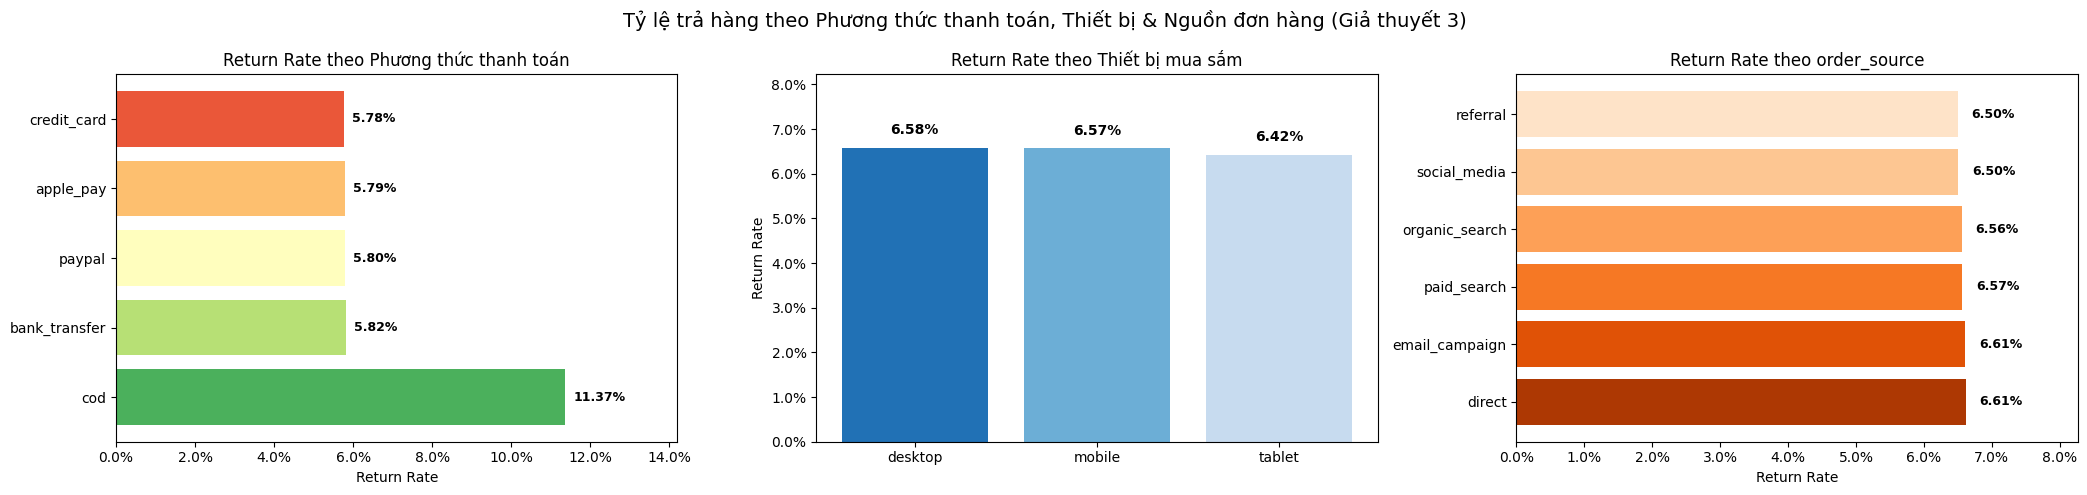

Đã lưu biểu đồ Phase 5: B:\DA_VSF\customer_churn_PL\report_11_6_2026\eda_outputs\figures\eda_phase5_payment_and_device_impact.png


In [16]:
# ── 3. Vẽ biểu đồ tổng hợp Phase 5 ──
n_panels = sum([pay_col is not None, dev_col is not None, src_col is not None])
fig, axes = plt.subplots(1, n_panels, figsize=(7 * n_panels, 5))
if n_panels == 1:
    axes = [axes]
fig.suptitle('Tỷ lệ trả hàng theo Phương thức thanh toán, Thiết bị & Nguồn đơn hàng (Giả thuyết 3)', fontsize=14)

ax_idx = 0

# Panel 1: Payment Method
if pay_col:
    ax = axes[ax_idx]
    bars = ax.barh(pay_rate[pay_col], pay_rate['return_rate'], color=sns.color_palette('RdYlGn_r', len(pay_rate)))
    ax.set_title('Return Rate theo Phương thức thanh toán')
    ax.set_xlabel('Return Rate')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    ax.set_xlim(0, pay_rate['return_rate'].max() * 1.25)
    for bar, val in zip(bars, pay_rate['return_rate']):
        ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                f'{val:.2%}', va='center', fontweight='bold', fontsize=9)
    ax_idx += 1

# Panel 2: Device Type
if dev_col:
    ax = axes[ax_idx]
    palette = sns.color_palette('Blues_r', len(dev_rate))
    bars = ax.bar(dev_rate[dev_col], dev_rate['return_rate'], color=palette)
    ax.set_title('Return Rate theo Thiết bị mua sắm')
    ax.set_ylabel('Return Rate')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    ax.set_ylim(0, dev_rate['return_rate'].max() * 1.25)
    for bar, val in zip(bars, dev_rate['return_rate']):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 0.003,
                f'{val:.2%}', ha='center', fontweight='bold', fontsize=10)
    ax_idx += 1

# Panel 3: Source / Channel
if src_col:
    ax = axes[ax_idx]
    bars = ax.barh(src_rate[src_col], src_rate['return_rate'], color=sns.color_palette('Oranges_r', len(src_rate)))
    ax.set_title(f'Return Rate theo {src_col}')
    ax.set_xlabel('Return Rate')
    ax.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    ax.set_xlim(0, src_rate['return_rate'].max() * 1.25)
    for bar, val in zip(bars, src_rate['return_rate']):
        ax.text(val + 0.002, bar.get_y() + bar.get_height() / 2,
                f'{val:.2%}', va='center', fontweight='bold', fontsize=9)
    ax_idx += 1

plt.tight_layout()
output_path = EDA_FIGURE_DIR / 'eda_phase5_payment_and_device_impact.png'
fig.savefig(output_path, dpi=150, bbox_inches='tight')
plt.show()
print(f'Đã lưu biểu đồ Phase 5: {output_path}')


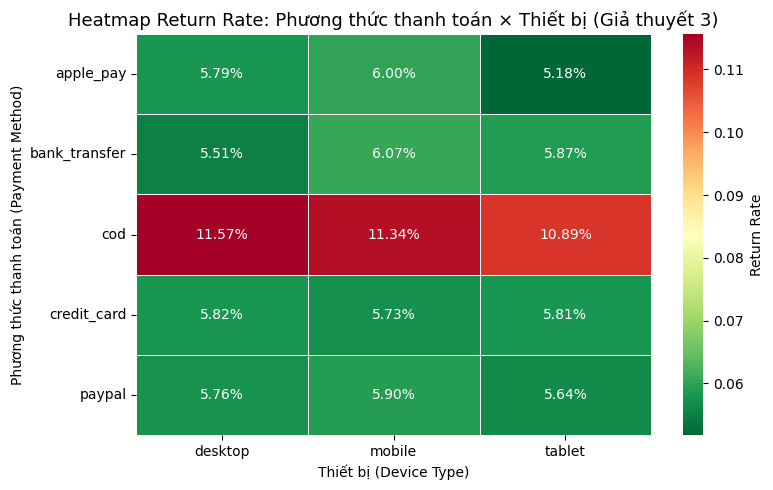

Đã lưu heatmap tương tác: B:\DA_VSF\customer_churn_PL\report_11_6_2026\eda_outputs\figures\eda_phase5_heatmap_payment_x_device.png


In [17]:
# ── 4. Phân tích heatmap chéo: Payment × Device ──
if pay_col and dev_col:
    cross = df_master.groupby([pay_col, dev_col])['returned_label'].mean().unstack()
    cross.to_csv(EDA_TABLE_DIR / 'eda_phase5_cross_payment_device.csv')

    fig, ax = plt.subplots(figsize=(8, 5))
    sns.heatmap(
        cross,
        annot=True, fmt='.2%', cmap='RdYlGn_r',
        linewidths=0.5, ax=ax,
        cbar_kws={'label': 'Return Rate'}
    )
    ax.set_title('Heatmap Return Rate: Phương thức thanh toán × Thiết bị (Giả thuyết 3)', fontsize=13)
    ax.set_xlabel('Thiết bị (Device Type)')
    ax.set_ylabel('Phương thức thanh toán (Payment Method)')
    plt.tight_layout()
    output_heatmap = EDA_FIGURE_DIR / 'eda_phase5_heatmap_payment_x_device.png'
    fig.savefig(output_heatmap, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Đã lưu heatmap tương tác: {output_heatmap}')


## Kết luận Phase 5: Phương thức thanh toán, thiết bị và nguồn đơn hàng

- **Phương thức thanh toán (`payment_method`)**  
  `cod` có Return Rate khoảng **11.37%**, cao gần gấp đôi các phương thức khác như `credit_card`, `paypal`, `apple_pay`, `bank_transfer` chỉ quanh **5.8%**. Đây là tín hiệu rõ nhất trong Phase 5.  
  **Kết luận:** `is_cod` và `payment_method` là feature mạnh, nên đưa vào Feature Engineering ở mức **High**.

- **Thiết bị mua hàng (`device_type`)**  
  Return Rate theo thiết bị rất gần nhau: `desktop` khoảng **6.58%**, `mobile` khoảng **6.57%**, `tablet` khoảng **6.42%**. Không có bằng chứng rõ rằng mobile làm tăng trả hàng.  
  **Kết luận:** `device_type` chỉ nên là feature hỗ trợ; không cần tạo thêm cờ riêng cho từng loại thiết bị trong v1.

- **Nguồn đơn hàng (`order_source`)**  
  Return Rate theo nguồn đơn hàng dao động rất nhẹ, khoảng **6.50%-6.61%**. `social_media` không phải nhóm cao nhất; thực tế gần baseline.  
  **Kết luận:** `order_source` nên giữ ở mức **Medium / Supporting**; không cần tạo thêm cờ riêng cho từng nguồn đơn trong v1.

- **Tương tác `payment_method × device_type`**  
  Heatmap cho thấy nhóm COD luôn có Return Rate cao trên cả desktop, mobile và tablet. Điều này chứng tỏ tín hiệu chính đến từ `payment_method = cod`, không phải riêng combo `cod_mobile`.  
  **Kết luận:** `payment_device_interaction` có thể thử ở mức **Low/Experimental**, nhưng không nên overstating rằng mobile là nguyên nhân.

- **Kết luận chung Phase 5**  
  Giả thuyết về COD được xác nhận rõ, nhưng giả thuyết về mobile và social media không được ủng hộ mạnh. Phase 5 cho thấy payment method là nhóm feature quan trọng nhất.

**Feature đề xuất từ Phase 5:**
- `is_cod` - High
- `payment_method` - High
- `device_type` - Medium / Supporting
- `order_source` - Medium / Supporting
- `payment_device_interaction` - Low / Experimental


---
## Phase 6 - Kiểm chứng Giả thuyết 4: Giá trị & Quy mô đơn hàng (Order Value & Quantity)
### Mục tiêu
- Kiểm chứng phát biểu: *"Giá trị đơn hàng, số lượng sản phẩm và mức giảm giá có ảnh hưởng tới xác suất trả hàng hay không."*

### Việc cần làm
- Phân nhóm `payment_value` theo **quantile** thay vì ngưỡng cố định, vì giá trị thanh toán trong dữ liệu nằm trên thang đo lớn (min khoảng 389.74, median khoảng 17k).
- Tính Return Rate cho từng nhóm giá trị đơn hàng và vẽ biểu đồ.
- Phân tích mối quan hệ giữa `quantity` và Return Rate.
- Phân tích ảnh hưởng của giảm giá bằng `is_discounted` và `discount_ratio = discount_amount / unit_price`.
- Không thêm `price_vs_category_avg` ở v1 vì dễ làm Phase 6 bị rộng và trùng với Product Features.
- Lưu biểu đồ và bảng thống kê.


In [18]:
# ── 1. Phân nhóm payment_value theo quantile ──
# Lý do: ngưỡng cố định [0, 50, 200, 500, inf] không phù hợp với scale dữ liệu.
# payment_value thực tế bắt đầu khoảng vài trăm và median khoảng 17k, nên các bucket thấp bị trống.

payment_value_labels = [
    'Q1_lowest',
    'Q2_low',
    'Q3_high',
    'Q4_highest',
]

df_master['payment_value_group'] = pd.qcut(
    df_master['payment_value'],
    q=4,
    labels=payment_value_labels,
    duplicates='drop'
)

pay_val_rate = (
    df_master.groupby('payment_value_group', observed=True)
    .agg(
        return_rate=('returned_label', 'mean'),
        n_orders=('returned_label', 'count'),
        min_payment_value=('payment_value', 'min'),
        max_payment_value=('payment_value', 'max'),
    )
    .reset_index()
)

pay_val_rate.to_csv(EDA_TABLE_DIR / 'eda_phase6_return_rate_by_payment_value.csv', index=False)

print('=== Return Rate theo Khoảng giá trị đơn hàng (Quantile) ===')
print(pay_val_rate.to_string(index=False))


=== Return Rate theo Khoảng giá trị đơn hàng (Quantile) ===
payment_value_group  return_rate  n_orders  min_payment_value  max_payment_value
          Q1_lowest     0.066910    152728             428.20            7653.40
             Q2_low     0.066296    152725            7653.42           16826.79
            Q3_high     0.064383    152726           16826.82           33207.44
         Q4_highest     0.064527    152727           33207.54          331570.40


In [19]:
# ── 2. Return Rate theo số lượng (quantity) ──
if 'quantity' in df_master.columns:
    qty_rate = (
        df_master.groupby('quantity')['returned_label']
        .agg(['mean', 'count'])
        .reset_index()
    )
    qty_rate.columns = ['quantity', 'return_rate', 'n_orders']
    qty_rate.to_csv(EDA_TABLE_DIR / 'eda_phase6_return_rate_by_quantity.csv', index=False)
    print('=== Return Rate theo Số lượng sản phẩm (quantity) ===')
    print(qty_rate.to_string(index=False))
else:
    qty_rate = None
    print('Cột quantity không tồn tại trong df_master')


=== Return Rate theo Số lượng sản phẩm (quantity) ===
 quantity  return_rate  n_orders
        1     0.066302     76725
        2     0.066218     76414
        3     0.064666     76470
        4     0.066060     76234
        5     0.065615     76537
        6     0.065248     76524
        7     0.065016     76473
        8     0.065101     75529


In [20]:
# ── 3. Phân tích giảm giá bằng is_discounted và discount_ratio ──
if {'discount_amount', 'unit_price'}.issubset(df_master.columns):
    df_master['is_discounted'] = (df_master['discount_amount'].fillna(0) > 0).astype(int)
    df_master['discount_ratio'] = np.where(
        df_master['unit_price'].fillna(0) > 0,
        df_master['discount_amount'].fillna(0) / df_master['unit_price'],
        0
    )
    df_master['discount_ratio'] = df_master['discount_ratio'].clip(lower=0)

    discounted_rate = (
        df_master.groupby('is_discounted')['returned_label']
        .agg(['mean', 'count'])
        .reset_index()
    )
    discounted_rate.columns = ['is_discounted', 'return_rate', 'n_orders']
    discounted_rate['discount_status'] = discounted_rate['is_discounted'].map({0: 'Không giảm giá', 1: 'Có giảm giá'})

    ratio_bins = [-0.001, 0, 0.05, 0.20, float('inf')]
    ratio_labels = ['Không giảm', 'Giảm nhẹ (<=5%)', 'Giảm vừa (5%-20%)', 'Giảm mạnh (>20%)']
    df_master['discount_ratio_group'] = pd.cut(
        df_master['discount_ratio'],
        bins=ratio_bins,
        labels=ratio_labels,
        right=True
    )

    disc_rate = (
        df_master.groupby('discount_ratio_group', observed=True)
        .agg(
            return_rate=('returned_label', 'mean'),
            n_orders=('returned_label', 'count'),
            min_discount_ratio=('discount_ratio', 'min'),
            max_discount_ratio=('discount_ratio', 'max'),
        )
        .reset_index()
    )

    discounted_rate.to_csv(EDA_TABLE_DIR / 'eda_phase6_return_rate_by_is_discounted.csv', index=False)
    disc_rate.to_csv(EDA_TABLE_DIR / 'eda_phase6_return_rate_by_discount_ratio.csv', index=False)

    print('=== Return Rate theo Có/Không có giảm giá ===')
    print(discounted_rate[['discount_status', 'return_rate', 'n_orders']].to_string(index=False))
    print('\n=== Return Rate theo Tỷ lệ giảm giá (discount_ratio) ===')
    print(disc_rate.to_string(index=False))
else:
    discounted_rate = None
    disc_rate = None
    print('Không tìm thấy đủ cột discount_amount và unit_price trong df_master')


=== Return Rate theo Có/Không có giảm giá ===
discount_status  return_rate  n_orders
 Không giảm giá     0.065394    374684
    Có giảm giá     0.065743    236222

=== Return Rate theo Tỷ lệ giảm giá (discount_ratio) ===
discount_ratio_group  return_rate  n_orders  min_discount_ratio  max_discount_ratio
          Không giảm     0.065394    374684            0.000000            0.000000
     Giảm nhẹ (<=5%)     0.065748      7696            0.004180            0.049988
   Giảm vừa (5%-20%)     0.066107     36698            0.050004            0.200000
    Giảm mạnh (>20%)     0.065673    191828            0.200000            1.600007


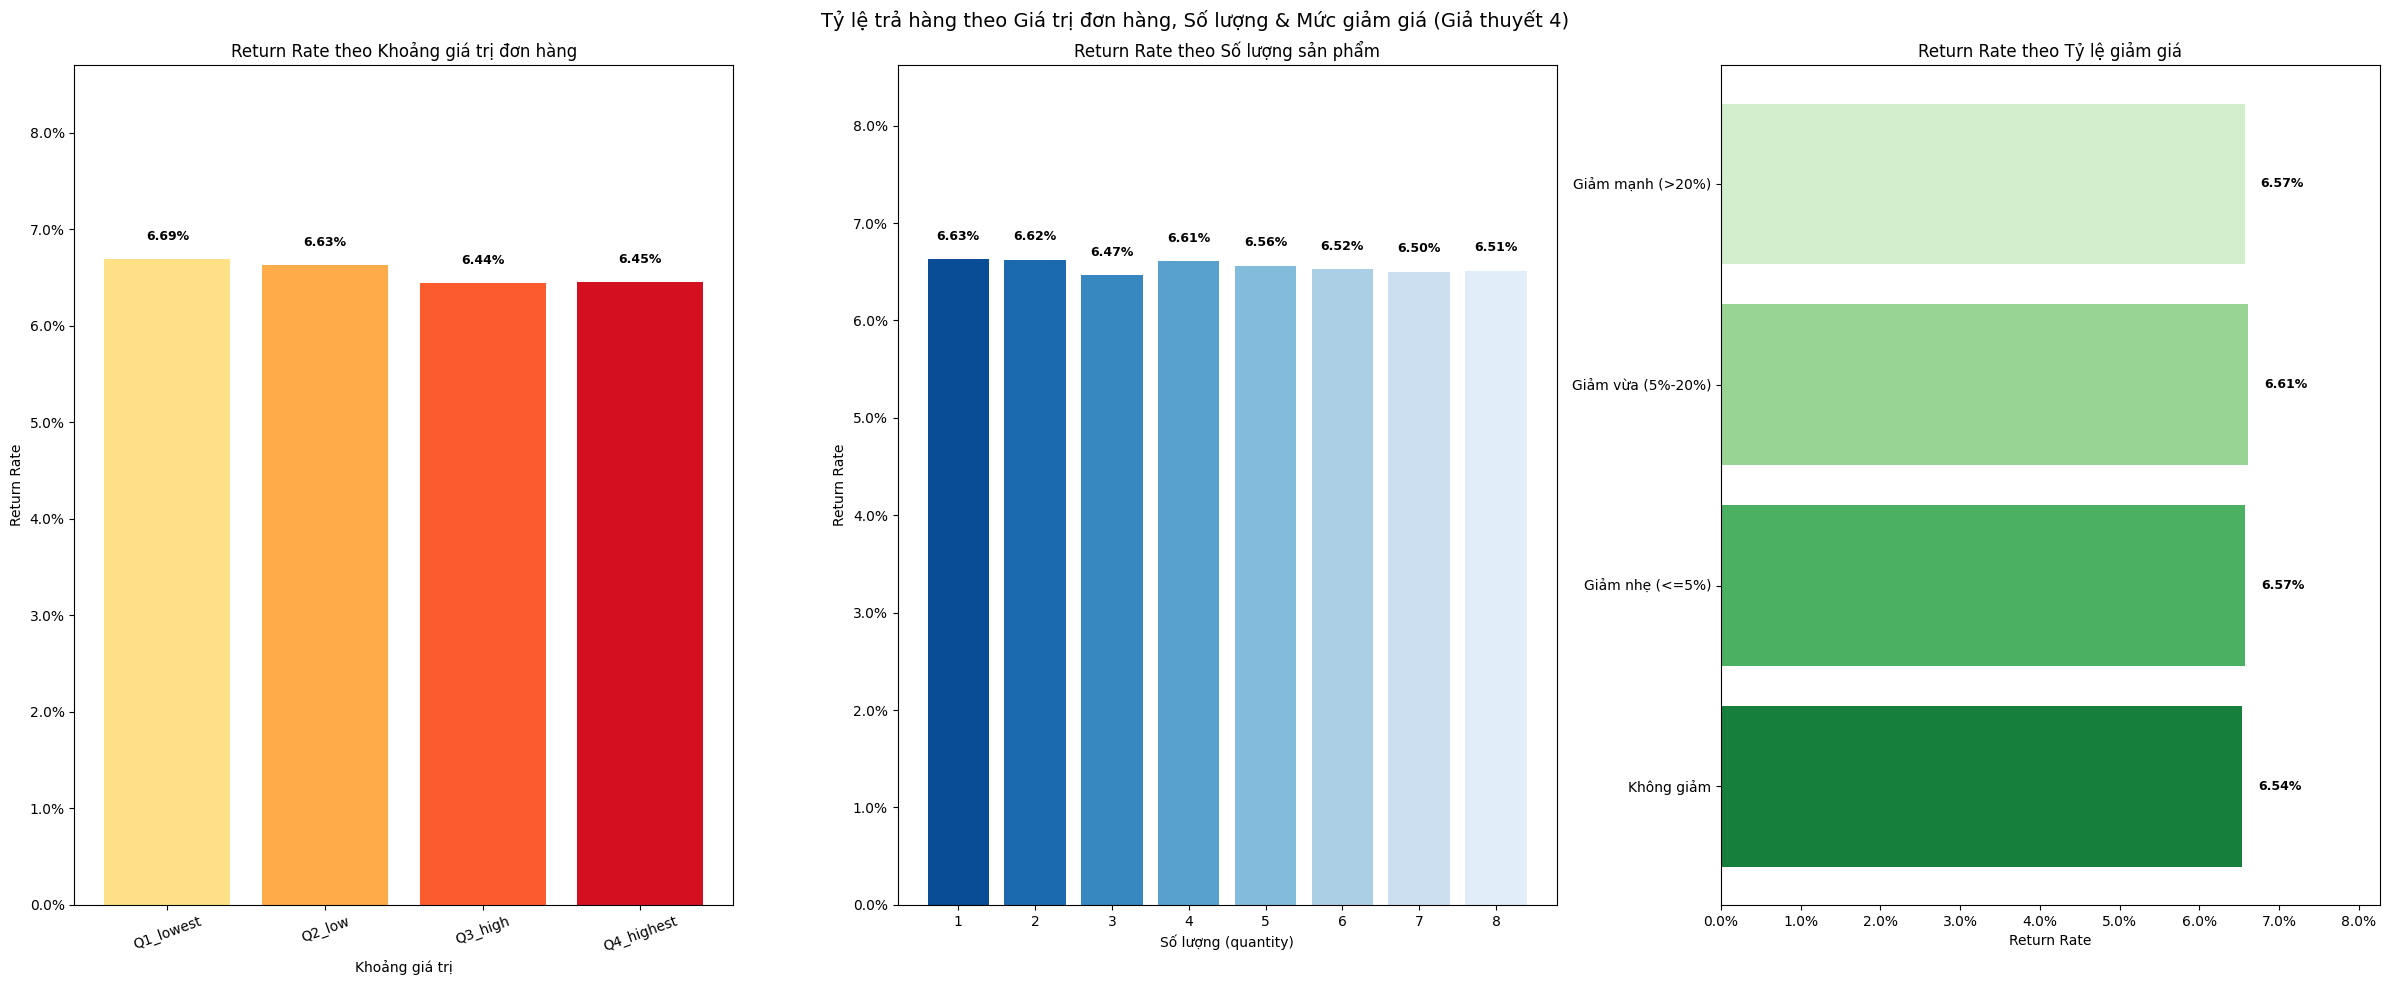

Đã lưu biểu đồ Phase 6: B:\DA_VSF\customer_churn_PL\report_11_6_2026\eda_outputs\figures\eda_phase6_return_rate_by_order_value.png


In [21]:
# ── 4. Vẽ biểu đồ tổng hợp Phase 6 ──
fig, axes = plt.subplots(1, 3, figsize=(24, 10))
fig.suptitle('Tỷ lệ trả hàng theo Giá trị đơn hàng, Số lượng & Mức giảm giá (Giả thuyết 4)', fontsize=14)

# Panel 1: Payment Value Group
ax0 = axes[0]
colors = sns.color_palette('YlOrRd', len(pay_val_rate))
bars = ax0.bar(pay_val_rate['payment_value_group'], pay_val_rate['return_rate'], color=colors)
ax0.set_title('Return Rate theo Khoảng giá trị đơn hàng')
ax0.set_ylabel('Return Rate')
ax0.set_xlabel('Khoảng giá trị')
ax0.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax0.set_ylim(0, pay_val_rate['return_rate'].max() * 1.3)
ax0.tick_params(axis='x', rotation=20)
for bar, val in zip(bars, pay_val_rate['return_rate']):
    ax0.text(bar.get_x() + bar.get_width()/2, val + 0.002,
             f'{val:.2%}', ha='center', fontweight='bold', fontsize=9)

# Panel 2: Quantity
ax1 = axes[1]
if qty_rate is not None and not qty_rate.empty:
    ax1.bar(qty_rate['quantity'].astype(str), qty_rate['return_rate'],
            color=sns.color_palette('Blues_r', len(qty_rate)))
    ax1.set_title('Return Rate theo Số lượng sản phẩm')
    ax1.set_ylabel('Return Rate')
    ax1.set_xlabel('Số lượng (quantity)')
    ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    ax1.set_ylim(0, qty_rate['return_rate'].max() * 1.3)
    for i, (_, row) in enumerate(qty_rate.iterrows()):
        ax1.text(i, row['return_rate'] + 0.002, f'{row["return_rate"]:.2%}',
                 ha='center', fontweight='bold', fontsize=9)
else:
    ax1.text(0.5, 0.5, 'Không có dữ liệu quantity', ha='center', va='center', transform=ax1.transAxes)
    ax1.set_title('Return Rate theo Số lượng sản phẩm')

# Panel 3: Discount Group
ax2 = axes[2]
if disc_rate is not None and not disc_rate.empty:
    colors_d = sns.color_palette('Greens_r', len(disc_rate))
    bars_d = ax2.barh(disc_rate['discount_ratio_group'], disc_rate['return_rate'], color=colors_d)
    ax2.set_title('Return Rate theo Tỷ lệ giảm giá')
    ax2.set_xlabel('Return Rate')
    ax2.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    ax2.set_xlim(0, disc_rate['return_rate'].max() * 1.25)
    for bar, val in zip(bars_d, disc_rate['return_rate']):
        ax2.text(val + 0.002, bar.get_y() + bar.get_height()/2,
                 f'{val:.2%}', va='center', fontweight='bold', fontsize=9)
else:
    ax2.text(0.5, 0.5, 'Không có dữ liệu discount', ha='center', va='center', transform=ax2.transAxes)
    ax2.set_title('Return Rate theo Mức giảm giá')

plt.tight_layout()
output_path6 = EDA_FIGURE_DIR / 'eda_phase6_return_rate_by_order_value.png'
fig.savefig(output_path6, dpi=150, bbox_inches='tight')
plt.show()
print(f'Đã lưu biểu đồ Phase 6: {output_path6}')


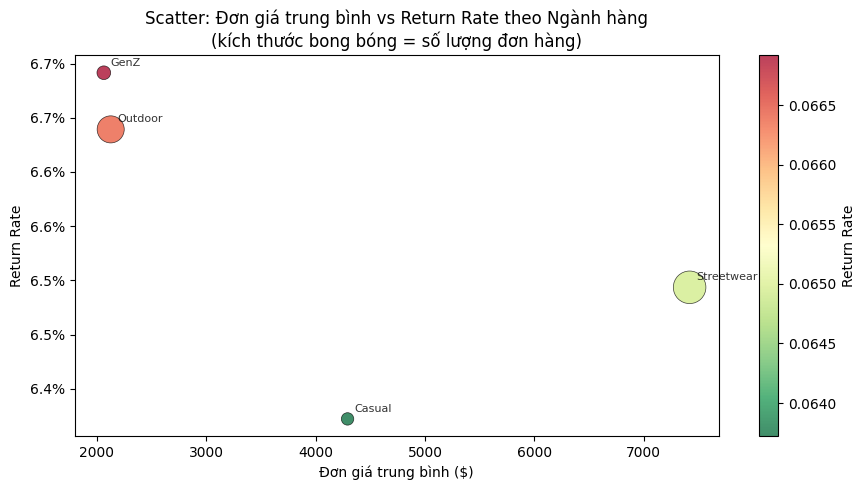

Đã lưu scatter plot: B:\DA_VSF\customer_churn_PL\report_11_6_2026\eda_outputs\figures\eda_phase6_scatter_price_vs_returnrate.png


In [22]:
# ── 5. Scatter plot: unit_price vs Return Rate theo category ──
if 'unit_price' in df_master.columns and 'category' in df_master.columns:
    scatter_data = (
        df_master.groupby('category')
        .agg(avg_price=('unit_price', 'mean'), return_rate=('returned_label', 'mean'), n=('returned_label', 'count'))
        .reset_index()
    )

    fig, ax = plt.subplots(figsize=(9, 5))
    scatter = ax.scatter(
        scatter_data['avg_price'],
        scatter_data['return_rate'],
        s=scatter_data['n'] / scatter_data['n'].max() * 500 + 50,
        alpha=0.75,
        c=scatter_data['return_rate'],
        cmap='RdYlGn_r',
        edgecolors='black',
        linewidths=0.5
    )
    for _, row in scatter_data.iterrows():
        ax.annotate(row['category'], (row['avg_price'], row['return_rate']),
                    textcoords='offset points', xytext=(5, 5), fontsize=8, alpha=0.8)
    plt.colorbar(scatter, ax=ax, label='Return Rate')
    ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
    ax.set_xlabel('Đơn giá trung bình ($)')
    ax.set_ylabel('Return Rate')
    ax.set_title('Scatter: Đơn giá trung bình vs Return Rate theo Ngành hàng\n(kích thước bong bóng = số lượng đơn hàng)')
    plt.tight_layout()
    output_scatter = EDA_FIGURE_DIR / 'eda_phase6_scatter_price_vs_returnrate.png'
    fig.savefig(output_scatter, dpi=150, bbox_inches='tight')
    plt.show()
    print(f'Đã lưu scatter plot: {output_scatter}')


## Kết luận Phase 6: Giá trị & Quy mô đơn hàng

- **Giá trị đơn hàng (`payment_value`)**  
  Sau khi chia `payment_value` theo quantile, Return Rate giữa 4 nhóm giá trị khá sát nhau: `Q1_lowest` là **6.69%**, `Q2_low` là **6.63%**, `Q3_high` là **6.44%**, và `Q4_highest` là **6.45%**. Nhóm đơn giá trị thấp có tỷ lệ trả hàng nhỉnh hơn nhẹ, nhưng chênh lệch không lớn. Vì vậy, chưa thể kết luận giá trị đơn hàng là yếu tố tác động mạnh đến hành vi trả hàng.  
  **Kết luận:** `payment_value` nên được giữ làm feature hỗ trợ. Khi Feature Engineering, nên dùng thêm `log_payment_value` hoặc `payment_value_quantile_bucket` thay vì bucket cố định.

- **Số lượng sản phẩm (`quantity`)**  
  Return Rate theo số lượng sản phẩm dao động quanh mức **6.5%-6.6%**. Các đơn có quantity thấp hay cao không tạo ra xu hướng tăng/giảm rõ ràng về tỷ lệ trả hàng. Điều này cho thấy số lượng sản phẩm trong đơn không phải biến phân tách mạnh nếu xét riêng lẻ.  
  **Kết luận:** `quantity` có thể giữ làm feature nền tảng, nhưng chỉ nên xếp mức **Medium / Supporting**.

- **Mức giảm giá (`discount_amount`)**  
  Đơn có giảm giá chỉ cao hơn đơn không giảm giá rất nhẹ: khoảng **6.57%** so với **6.54%**. Khi chia theo `discount_ratio`, các nhóm cũng chỉ quanh **6.54%-6.61%**. Mức chênh lệch nhỏ và chưa đủ để kết luận giảm giá là nguyên nhân chính làm tăng trả hàng.  
  **Kết luận:** Nên tạo `is_discounted` và `discount_ratio`, nhưng chỉ xem là feature hỗ trợ, cần model kiểm chứng thêm.

- **Kết luận chung Phase 6**  
  Giả thuyết “giá trị đơn hàng, số lượng sản phẩm hoặc mức giảm giá ảnh hưởng mạnh đến tỷ lệ trả hàng” **không được xác nhận rõ** qua EDA. Các biến giao dịch trong Phase 6 đều có tín hiệu yếu khi xét riêng lẻ. Tuy nhiên, chúng vẫn nên được giữ lại vì có ý nghĩa nghiệp vụ, dễ tạo, và có thể hữu ích khi kết hợp với các biến khác như `payment_method`, `is_cod`, `category`, hoặc lịch sử khách hàng/sản phẩm.

**Feature đề xuất từ Phase 6:**
- `payment_value` - Medium / Supporting
- `log_payment_value` - Medium / Supporting
- `payment_value_quantile_bucket` - Medium / Supporting
- `quantity` -  Medium / Supporting
- `discount_ratio` - Medium / Supporting
- `is_discounted` -  Medium / Supporting


---
## Phase 7 - Kiểm chứng Giả thuyết 5: Yếu tố Thời gian & Mùa vụ (Time & Seasonality)
### Mục tiêu
- Kiểm chứng phát biểu: *"Tỷ lệ trả hàng tăng mạnh vào các mùa mua sắm cao điểm (cuối năm, dịp lễ) do vận chuyển chậm hoặc mua quà không phù hợp."*

### Việc cần làm
- Trích xuất từ `order_date`: `order_month`, `order_day_of_week`, `order_quarter`, `is_weekend`.
- Vẽ biểu đồ đường xu hướng Return Rate theo từng tháng (12 tháng).
- Phân tích Return Rate theo thứ trong tuần (Monday-Sunday).
- So sánh Return Rate giữa cuối tuần (Sat, Sun) vs ngày thường.
- Vẽ heatmap Return Rate theo Tháng × Thứ.


In [23]:
# ── 1. Trích xuất các đặc trưng thời gian ──
df_master['order_month']       = df_master['order_date'].dt.month
df_master['order_day_of_week'] = df_master['order_date'].dt.dayofweek  # 0=Mon, 6=Sun
df_master['order_quarter']     = df_master['order_date'].dt.quarter
df_master['is_weekend']        = df_master['order_day_of_week'].isin([5, 6]).astype(int)
df_master['order_year']        = df_master['order_date'].dt.year

MONTH_LABELS = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun',
                'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']
DOW_LABELS   = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']

# Return Rate theo tháng
monthly_rate = (
    df_master.groupby('order_month')['returned_label']
    .agg(['mean', 'count'])
    .reindex(range(1, 13))
    .reset_index()
)
monthly_rate.columns = ['order_month', 'return_rate', 'n_orders']
monthly_rate['month_label'] = monthly_rate['order_month'].apply(lambda m: MONTH_LABELS[m-1])
monthly_rate.to_csv(EDA_TABLE_DIR / 'eda_phase7_return_rate_by_month.csv', index=False)
print('=== Return Rate theo Tháng ===')
print(monthly_rate[['month_label', 'return_rate', 'n_orders']].to_string(index=False))


=== Return Rate theo Tháng ===
month_label  return_rate  n_orders
        Jan     0.063965     28500
        Feb     0.065462     33210
        Mar     0.064034     53831
        Apr     0.066137     69296
        May     0.066431     68552
        Jun     0.062822     66840
        Jul     0.066706     57941
        Aug     0.066434     61339
        Sep     0.066901     45769
        Oct     0.067881     37669
        Nov     0.066158     34992
        Dec     0.063776     52967


In [24]:
# ── 2. Return Rate theo thứ trong tuần ──
dow_rate = (
    df_master.groupby('order_day_of_week')['returned_label']
    .agg(['mean', 'count'])
    .reindex(range(7))
    .reset_index()
)
dow_rate.columns = ['order_day_of_week', 'return_rate', 'n_orders']
dow_rate['day_label'] = dow_rate['order_day_of_week'].apply(lambda d: DOW_LABELS[d])
dow_rate.to_csv(EDA_TABLE_DIR / 'eda_phase7_return_rate_by_dayofweek.csv', index=False)
print('=== Return Rate theo Thứ trong tuần ===')
print(dow_rate[['day_label', 'return_rate', 'n_orders']].to_string(index=False))

# Weekend vs Weekday
weekend_rate = df_master.groupby('is_weekend')['returned_label'].mean()
print('\n=== Return Rate: Weekday (0) vs Weekend (1) ===')
print(weekend_rate)


=== Return Rate theo Thứ trong tuần ===
day_label  return_rate  n_orders
      Mon     0.065069     88091
      Tue     0.065299     91242
      Wed     0.065233     95534
      Thu     0.066294     91396
      Fri     0.065604     82221
      Sat     0.066492     79303
      Sun     0.064775     83119

=== Return Rate: Weekday (0) vs Weekend (1) ===
is_weekend
0    0.065498
1    0.065613
Name: returned_label, dtype: float64


In [25]:
# ── 3. Return Rate theo Quý ──
quarter_rate = (
    df_master.groupby('order_quarter')['returned_label']
    .agg(['mean', 'count'])
    .reset_index()
)
quarter_rate.columns = ['quarter', 'return_rate', 'n_orders']
quarter_rate['quarter_label'] = quarter_rate['quarter'].apply(lambda q: f'Q{q}')
quarter_rate.to_csv(EDA_TABLE_DIR / 'eda_phase7_return_rate_by_quarter.csv', index=False)
print('=== Return Rate theo Quý ===')
print(quarter_rate[['quarter_label', 'return_rate', 'n_orders']].to_string(index=False))


=== Return Rate theo Quý ===


quarter_label  return_rate  n_orders
           Q1     0.064427    115541
           Q2     0.065153    204688
           Q3     0.066659    165049
           Q4     0.065670    125628


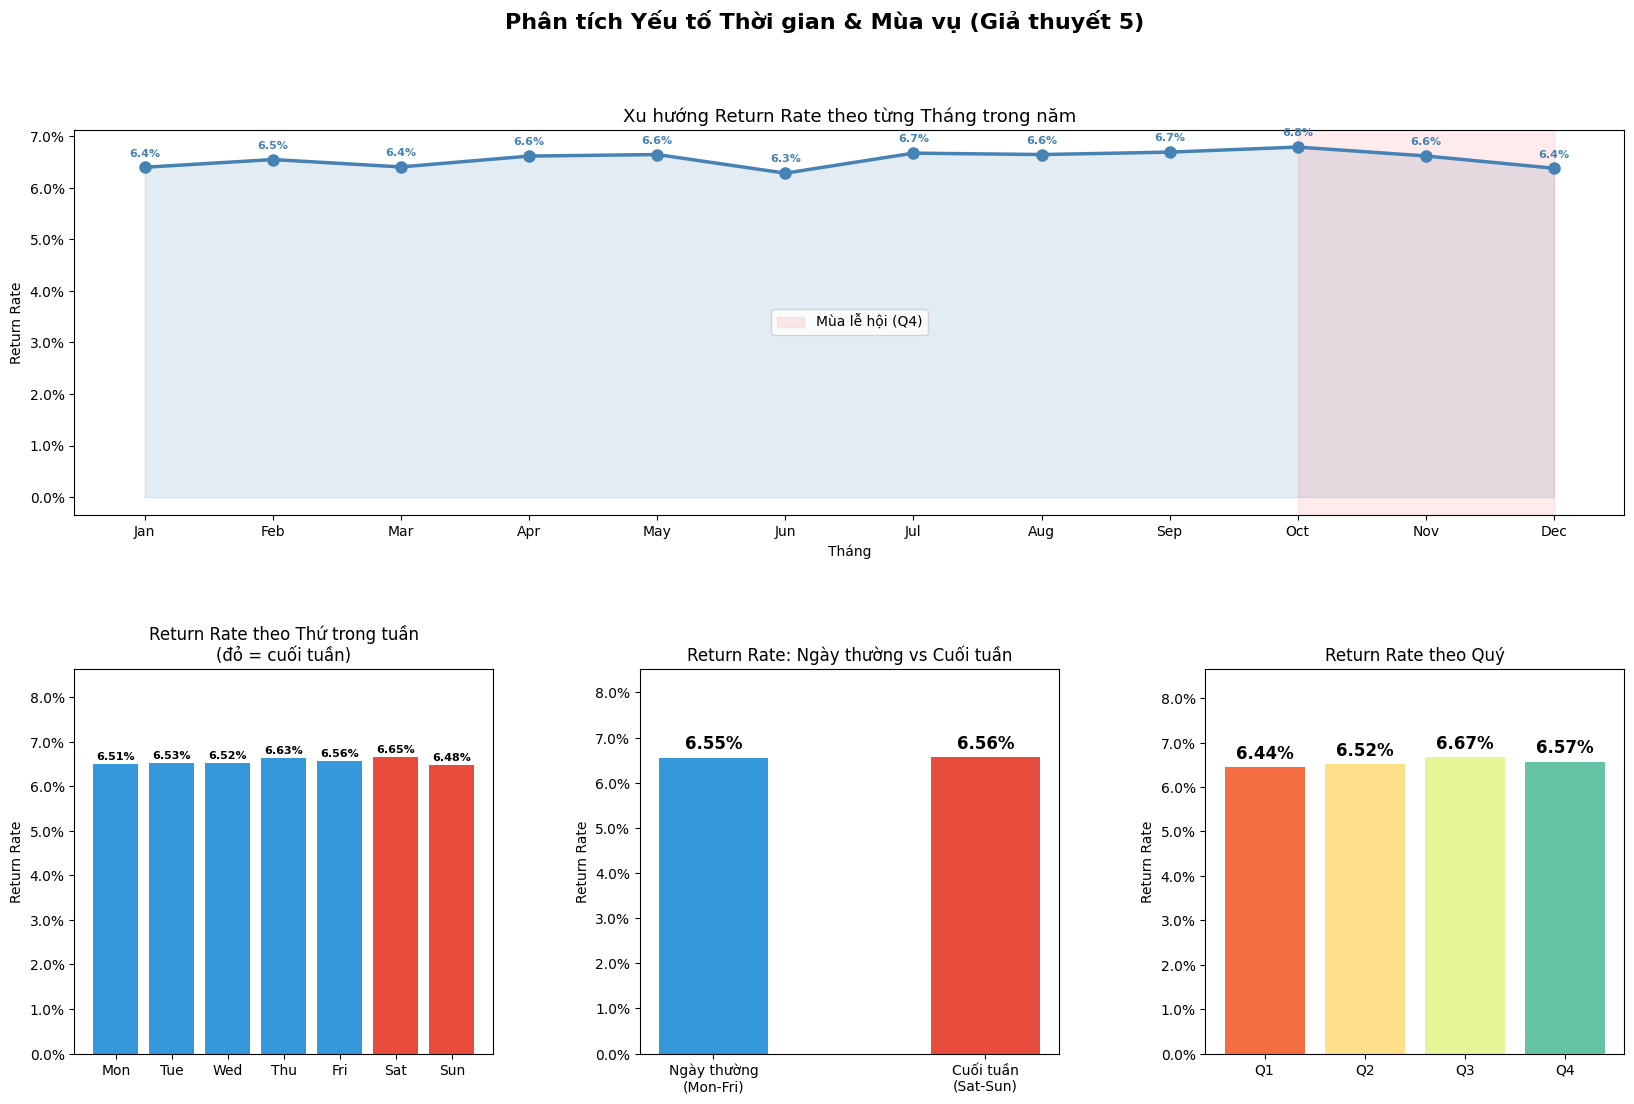

Đã lưu biểu đồ Phase 7: B:\DA_VSF\customer_churn_PL\report_11_6_2026\eda_outputs\figures\eda_phase7_seasonality_trend.png


In [26]:
# ── 4. Vẽ biểu đồ tổng hợp Phase 7 ──
fig = plt.figure(figsize=(20, 12))
fig.suptitle('Phân tích Yếu tố Thời gian & Mùa vụ (Giả thuyết 5)', fontsize=16, fontweight='bold')

gs = fig.add_gridspec(2, 3, hspace=0.4, wspace=0.35)

# ─ Panel 1: Xu hướng theo tháng (line chart) ─
ax1 = fig.add_subplot(gs[0, :])
valid_monthly = monthly_rate.dropna(subset=['return_rate'])
ax1.plot(valid_monthly['month_label'], valid_monthly['return_rate'],
         marker='o', linewidth=2.5, color='steelblue', markersize=8)
ax1.fill_between(valid_monthly['month_label'], valid_monthly['return_rate'],
                 alpha=0.15, color='steelblue')
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax1.set_title('Xu hướng Return Rate theo từng Tháng trong năm', fontsize=13)
ax1.set_xlabel('Tháng')
ax1.set_ylabel('Return Rate')
ax1.axvspan(9, 11, alpha=0.08, color='red', label='Mùa lễ hội (Q4)')
ax1.legend()
for _, row in valid_monthly.iterrows():
    ax1.annotate(f'{row["return_rate"]:.1%}',
                 (row['month_label'], row['return_rate']),
                 textcoords='offset points', xytext=(0, 8),
                 ha='center', fontsize=8, color='steelblue', fontweight='bold')

# ─ Panel 2: Return Rate theo thứ ─
ax2 = fig.add_subplot(gs[1, 0])
valid_dow = dow_rate.dropna(subset=['return_rate'])
palette_dow = ['#e74c3c' if d in [5, 6] else '#3498db' for d in valid_dow['order_day_of_week']]
bars2 = ax2.bar(valid_dow['day_label'], valid_dow['return_rate'], color=palette_dow)
ax2.set_title('Return Rate theo Thứ trong tuần\n(đỏ = cuối tuần)')
ax2.set_ylabel('Return Rate')
ax2.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax2.set_ylim(0, valid_dow['return_rate'].max() * 1.3)
for bar, val in zip(bars2, valid_dow['return_rate']):
    ax2.text(bar.get_x() + bar.get_width()/2, val + 0.001,
             f'{val:.2%}', ha='center', fontsize=8, fontweight='bold')

# ─ Panel 3: Weekday vs Weekend ─
ax3 = fig.add_subplot(gs[1, 1])
wd_labels = ['Ngày thường\n(Mon-Fri)', 'Cuối tuần\n(Sat-Sun)']
wd_colors = ['#3498db', '#e74c3c']
wd_vals   = [weekend_rate.get(0, 0), weekend_rate.get(1, 0)]
bars3 = ax3.bar(wd_labels, wd_vals, color=wd_colors, width=0.4)
ax3.set_title('Return Rate: Ngày thường vs Cuối tuần')
ax3.set_ylabel('Return Rate')
ax3.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax3.set_ylim(0, max(wd_vals) * 1.3)
for bar, val in zip(bars3, wd_vals):
    ax3.text(bar.get_x() + bar.get_width()/2, val + 0.002,
             f'{val:.2%}', ha='center', fontsize=12, fontweight='bold')

# ─ Panel 4: Return Rate theo Quý ─
ax4 = fig.add_subplot(gs[1, 2])
q_colors = sns.color_palette('Spectral', len(quarter_rate))
bars4 = ax4.bar(quarter_rate['quarter_label'], quarter_rate['return_rate'], color=q_colors)
ax4.set_title('Return Rate theo Quý')
ax4.set_ylabel('Return Rate')
ax4.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1, decimals=1))
ax4.set_ylim(0, quarter_rate['return_rate'].max() * 1.3)
for bar, val in zip(bars4, quarter_rate['return_rate']):
    ax4.text(bar.get_x() + bar.get_width()/2, val + 0.002,
             f'{val:.2%}', ha='center', fontsize=12, fontweight='bold')

output_path7 = EDA_FIGURE_DIR / 'eda_phase7_seasonality_trend.png'
fig.savefig(output_path7, dpi=150, bbox_inches='tight')
plt.show()
print(f'Đã lưu biểu đồ Phase 7: {output_path7}')


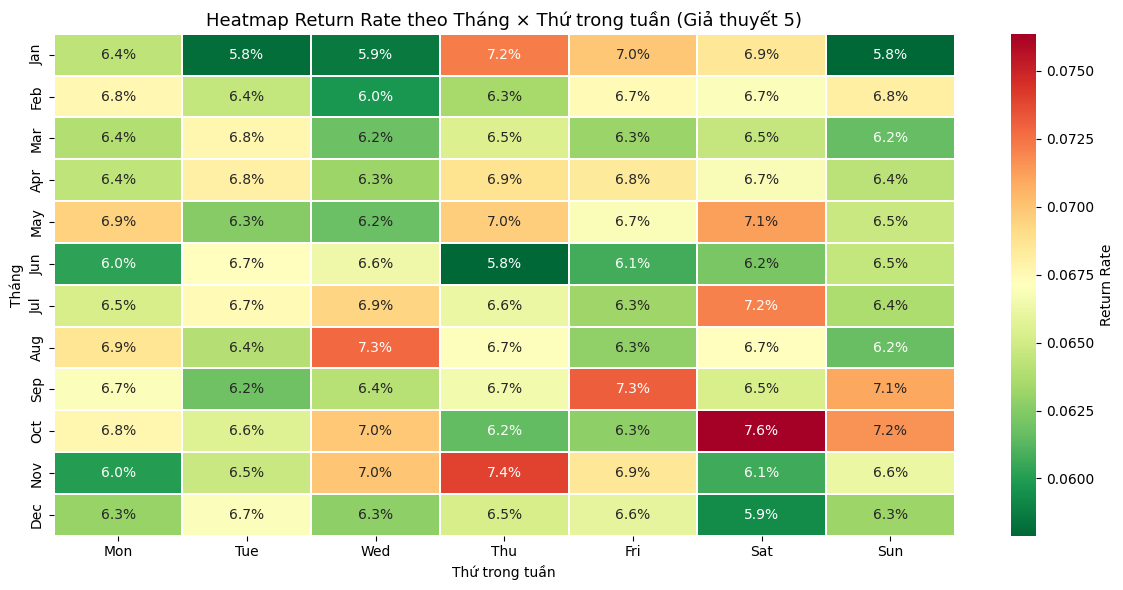

Đã lưu heatmap tháng × thứ: B:\DA_VSF\customer_churn_PL\report_11_6_2026\eda_outputs\figures\eda_phase7_heatmap_month_x_dow.png


In [27]:
# ── 5. Heatmap: Return Rate theo Tháng × Thứ trong tuần ──
heatmap_data = (
    df_master.groupby(['order_month', 'order_day_of_week'])['returned_label']
    .mean()
    .unstack()
)
heatmap_data.columns = [DOW_LABELS[i] for i in heatmap_data.columns]
heatmap_data.index   = [MONTH_LABELS[m-1] for m in heatmap_data.index]

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(
    heatmap_data,
    annot=True, fmt='.1%',
    cmap='RdYlGn_r',
    linewidths=0.3,
    ax=ax,
    cbar_kws={'label': 'Return Rate'}
)
ax.set_title('Heatmap Return Rate theo Tháng × Thứ trong tuần (Giả thuyết 5)', fontsize=13)
ax.set_xlabel('Thứ trong tuần')
ax.set_ylabel('Tháng')
plt.tight_layout()
output_heatmap7 = EDA_FIGURE_DIR / 'eda_phase7_heatmap_month_x_dow.png'
fig.savefig(output_heatmap7, dpi=150, bbox_inches='tight')
plt.show()
print(f'Đã lưu heatmap tháng × thứ: {output_heatmap7}')


## Kết luận Phase 7: Yếu tố thời gian & mùa vụ

- **Tỷ lệ trả hàng theo tháng (`order_month`)**  
  Return Rate theo tháng dao động quanh baseline khoảng **6.5%**. Tháng cao nhất là **tháng 10** với khoảng **6.79%**, tiếp theo là **tháng 9** khoảng **6.69%**, **tháng 7** khoảng **6.67%**. Tháng thấp nhất là **tháng 6** khoảng **6.28%** và **tháng 12** khoảng **6.38%**.  
  **Kết luận:** Có dao động nhẹ theo tháng, nhưng không đủ mạnh để xem tháng là driver chính. `order_month` chỉ nên là feature thời gian hỗ trợ.

- **Tỷ lệ trả hàng theo quý (`order_quarter`)**  
  Return Rate theo quý khá gần nhau: `Q1` khoảng **6.44%**, `Q2` khoảng **6.52%**, `Q3` cao nhất khoảng **6.67%**, và `Q4` khoảng **6.57%**. Q4 không phải quý cao nhất, nên giả thuyết “cuối năm/Q4 trả hàng cao hơn rõ rệt” không được xác nhận.  
  **Kết luận:** `order_quarter` có thể giữ làm feature thời gian, nhưng `is_q4` không nên coi là tín hiệu mạnh.

- **Tỷ lệ trả hàng theo thứ trong tuần (`order_day_of_week`)**  
  Return Rate theo ngày trong tuần dao động nhẹ: `Saturday` khoảng **6.65%**, `Thursday` khoảng **6.63%**, các ngày còn lại quanh **6.5%**, riêng `Sunday` thấp hơn nhẹ khoảng **6.48%**. Không có ngày nào tạo khác biệt đủ lớn.  
  **Kết luận:** `order_day_of_week` có thể giữ ở mức **Low/Experimental** hoặc supporting feature chi phí thấp.

- **Cuối tuần vs ngày thường (`is_weekend`)**  
  Return Rate ngày thường khoảng **6.55%**, cuối tuần khoảng **6.56%**. Hai giá trị gần như giống nhau, nên không có bằng chứng rằng mua cuối tuần làm tăng khả năng trả hàng.  
  **Kết luận:** `is_weekend` là feature yếu, chỉ nên để **Low/Experimental**.

- **Kết luận chung Phase 7**  
  Giả thuyết “mùa vụ, Q4 hoặc cuối tuần làm tăng tỷ lệ trả hàng” **không được xác nhận rõ**. Các biến thời gian có dao động nhẹ nhưng không tạo tín hiệu mạnh khi xét riêng lẻ. Tuy nhiên, chúng vẫn có thể giữ vì dễ tạo, chi phí thấp và có thể giúp model học một số pattern nhỏ theo lịch.

**Feature đề xuất từ Phase 7:**
- `order_month` - Low / Experimental
- `order_quarter` - Low / Experimental
- `order_day_of_week` - Low / Experimental
- `is_weekend` - Low / Experimental
- `is_q4` - Low / Experimental


---
## Phase 8 - Tổng hợp Insight cho Feature Engineering
### Mục tiêu
- Tổng hợp các insight đã kiểm chứng từ Phase 3-7 thành feature map cho bước Feature Engineering.
- Ghi rõ biến nào được EDA ủng hộ mạnh, biến nào chỉ nên giữ ở mức supporting/experimental.
- Đồng bộ lại Phase 8 với Phase 4 mới: `cap` được chuẩn hóa là `category` (ngành hàng), và interaction đúng là `gender × category`, không còn là `gender × size`.

### Quy ước mức độ ưu tiên
- **High**: Tín hiệu EDA rõ hoặc có ý nghĩa leakage-safe quan trọng, nên đưa vào feature set chính.
- **Medium**: Tín hiệu đơn lẻ yếu nhưng vẫn hữu ích làm supporting feature hoặc cần kiểm chứng qua model.
- **Low/Experimental**: Tương tác/phái sinh có tín hiệu chưa ổn định, chỉ thử nếu còn tài nguyên hoặc để model selection quyết định.


In [28]:
# Phase 8 - Feature Engineering map updated after EDA review
# Notes:
# - `cap` is standardized as `category` / ngành hàng.
# - Phase 4 analyzes gender x category, not gender x size.
# - Phase 6 payment_value now uses quantile buckets, not fixed bins.
# - Phase 5 and Phase 7 are kept from existing output tables; they were not expanded in the current revision pass.

feature_records = [
    {
        "hypothesis": "GS1 - Customer Profile",
        "eda_result": "Tenure groups differ only slightly around the baseline return rate (~6.5%).",
        "feature_candidate": "customer_tenure_days",
        "priority": "Medium",
        "decision_note": "Keep as a simple customer lifecycle feature; do not describe it as a strong standalone driver.",
    },
    {
        "hypothesis": "GS1 - Customer Profile",
        "eda_result": "Tenure bucket pattern is weak but business-interpretable.",
        "feature_candidate": "tenure_group",
        "priority": "Medium",
        "decision_note": "Use as supporting categorical feature; validate with model importance.",
    },
    {
        "hypothesis": "GS1 - Customer Profile",
        "eda_result": "Age group and gender do not show a clear standalone separation.",
        "feature_candidate": "age_group, gender",
        "priority": "Low/Experimental",
        "decision_note": "Keep only if encoding cost is low; do not claim strong EDA support.",
    },
    {
        "hypothesis": "GS2 - Product Features",
        "eda_result": "Single product attributes category, segment, size, and color are all close to baseline.",
        "feature_candidate": "category, segment, size, color",
        "priority": "Medium",
        "decision_note": "Use as supporting product descriptors; category is not High from EDA alone.",
    },
    {
        "hypothesis": "GS2 - Product Features",
        "eda_result": "Phase 4 analyzes gender x category; spread is larger than single product attributes but still needs validation.",
        "feature_candidate": "gender_category_interaction",
        "priority": "Low/Experimental",
        "decision_note": "Use the Phase 4 gender-category heatmap as the source for this interaction.",
    },
    {
        "hypothesis": "GS2 - Product Features",
        "eda_result": "Phase 4 still analyzes category x size through the category-size heatmap.",
        "feature_candidate": "category_size_interaction",
        "priority": "Low/Experimental",
        "decision_note": "Keep as experimental interaction for size-fit patterns by category.",
    },
    {
        "hypothesis": "GS2 - Product Features",
        "eda_result": "Top returned products have return rates around 10.7%-12.7%, clearly above the ~6.5% baseline.",
        "feature_candidate": "product_historical_return_rate, is_high_return_product",
        "priority": "High",
        "decision_note": "High / Advanced: create with train-time historical encoding / shift logic to avoid target leakage.",
    },
    {
        "hypothesis": "GS3 - Payment & Device",
        "eda_result": "COD return rate is about 11.37%, much higher than other payment methods around 5.8%.",
        "feature_candidate": "is_cod, payment_method",
        "priority": "High",
        "decision_note": "Strongest static transaction signal from EDA.",
    },
    {
        "hypothesis": "GS3 - Payment & Device",
        "eda_result": "Device type and order source are close to baseline; mobile and social media are not clearly higher.",
        "feature_candidate": "device_type, order_source",
        "priority": "Medium",
        "decision_note": "Keep as supporting categorical features, not as confirmed strong standalone drivers.",
    },
    {
        "hypothesis": "GS3 - Payment & Device",
        "eda_result": "Payment x device heatmap is dominated by COD; interaction may still help nonlinear models.",
        "feature_candidate": "payment_device_interaction",
        "priority": "Low/Experimental",
        "decision_note": "Try only as interaction feature; avoid overstating cod_mobile specifically.",
    },
    {
        "hypothesis": "GS4 - Order Value",
        "eda_result": "Payment value quantile buckets show weak separation only: Q1/Q2 are about 6.63%-6.69%, Q3/Q4 about 6.44%-6.45%.",
        "feature_candidate": "payment_value, log_payment_value, payment_value_quantile_bucket",
        "priority": "Medium",
        "decision_note": "Use raw/log/quantile value features as supporting features; do not treat order value as a strong standalone driver.",
    },
    {
        "hypothesis": "GS4 - Order Value",
        "eda_result": "Quantity ranges about 6.50%-6.63%; discount_ratio groups range about 6.54%-6.61%.",
        "feature_candidate": "quantity, discount_ratio, is_discounted",
        "priority": "Medium",
        "decision_note": "Use as standard transaction features; validate through model selection.",
    },
    {
        "hypothesis": "GS5 - Time & Seasonality",
        "eda_result": "Monthly/quarterly differences are mild; Q4 is not clearly the highest period.",
        "feature_candidate": "order_month, order_quarter, order_day_of_week",
        "priority": "Low/Experimental",
        "decision_note": "Low-cost calendar features, but not strong EDA drivers.",
    },
    {
        "hypothesis": "GS5 - Time & Seasonality",
        "eda_result": "Weekend vs weekday return rate is almost identical.",
        "feature_candidate": "is_weekend, is_q4",
        "priority": "Low/Experimental",
        "decision_note": "Keep only as optional binary calendar flags.",
    },
]

feature_df = pd.DataFrame(feature_records)
feature_df.to_csv(EDA_TABLE_DIR / "eda_phase8_feature_engineering_map.csv", index=False)

print("=== UPDATED FEATURE ENGINEERING MAP (EDA Phase 8) ===")
print(feature_df.to_string(index=False))

=== UPDATED FEATURE ENGINEERING MAP (EDA Phase 8) ===
              hypothesis                                                                                                      eda_result                                               feature_candidate         priority                                                                                                       decision_note
  GS1 - Customer Profile                                     Tenure groups differ only slightly around the baseline return rate (~6.5%).                                            customer_tenure_days           Medium                      Keep as a simple customer lifecycle feature; do not describe it as a strong standalone driver.
  GS1 - Customer Profile                                                       Tenure bucket pattern is weak but business-interpretable.                                                    tenure_group           Medium                                              Use as supporti

In [29]:
# Display feature candidates by hypothesis and priority
for hyp in feature_df["hypothesis"].unique():
    subset = feature_df[feature_df["hypothesis"] == hyp]
    counts = subset["priority"].value_counts().reindex(["High", "Medium", "Low/Experimental"], fill_value=0)
    print(f"\n{hyp} | High: {counts['High']} | Medium: {counts['Medium']} | Low/Experimental: {counts['Low/Experimental']}")
    print("-" * 100)
    for _, row in subset.iterrows():
        print(f"  {row['priority']:18s}  {row['feature_candidate']} -- {row['decision_note']}")



GS1 - Customer Profile | High: 0 | Medium: 2 | Low/Experimental: 1
----------------------------------------------------------------------------------------------------
  Medium              customer_tenure_days -- Keep as a simple customer lifecycle feature; do not describe it as a strong standalone driver.
  Medium              tenure_group -- Use as supporting categorical feature; validate with model importance.
  Low/Experimental    age_group, gender -- Keep only if encoding cost is low; do not claim strong EDA support.

GS2 - Product Features | High: 1 | Medium: 1 | Low/Experimental: 2
----------------------------------------------------------------------------------------------------
  Medium              category, segment, size, color -- Use as supporting product descriptors; category is not High from EDA alone.
  Low/Experimental    gender_category_interaction -- Use the Phase 4 gender-category heatmap as the source for this interaction.
  Low/Experimental    category_size_inte

In [30]:
# Priority summary for Phase 8 artifacts
priority_order = ["High", "Medium", "Low/Experimental"]
priority_summary = (
    feature_df["priority"]
    .value_counts()
    .reindex(priority_order, fill_value=0)
    .rename_axis("priority")
    .reset_index(name="n_feature_candidates")
)
priority_summary.to_csv(EDA_TABLE_DIR / "eda_phase8_feature_priority_summary.csv", index=False)

print("=== UPDATED PHASE 8 PRIORITY SUMMARY ===")
print(priority_summary.to_string(index=False))
print(f"\nTotal candidates: {len(feature_df)}")


=== UPDATED PHASE 8 PRIORITY SUMMARY ===
        priority  n_feature_candidates
            High                     2
          Medium                     6
Low/Experimental                     6

Total candidates: 14


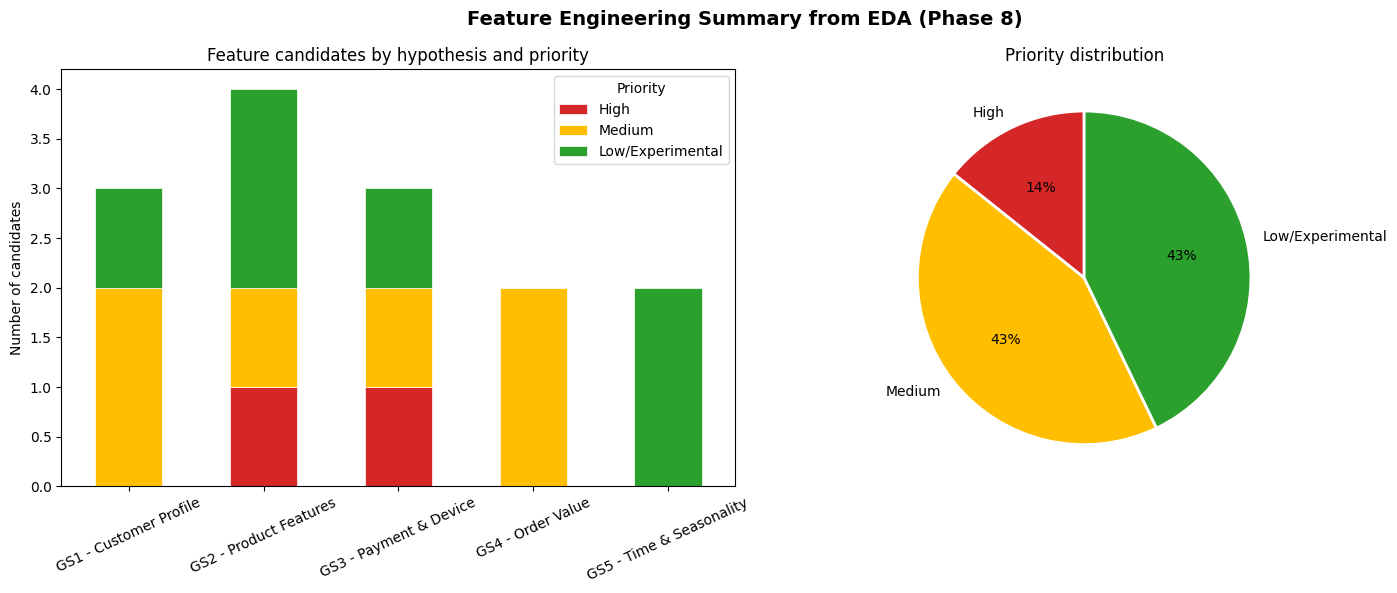

Saved updated Phase 8 summary chart: B:\DA_VSF\customer_churn_PL\report_11_6_2026\eda_outputs\figures\eda_phase8_feature_priority_summary.png


In [31]:
# Plot updated Phase 8 summary without emoji labels to avoid font warnings
priority_order = ["High", "Medium", "Low/Experimental"]
feature_pivot = (
    feature_df.groupby(["hypothesis", "priority"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=priority_order, fill_value=0)
)

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
fig.suptitle("Feature Engineering Summary from EDA (Phase 8)", fontsize=14, fontweight="bold")

colors_priority = {
    "High": "#d62728",
    "Medium": "#ffbf00",
    "Low/Experimental": "#2ca02c",
}
feature_pivot.plot(
    kind="bar",
    stacked=True,
    ax=axes[0],
    color=[colors_priority[c] for c in feature_pivot.columns],
    edgecolor="white",
    linewidth=0.5,
)
axes[0].set_title("Feature candidates by hypothesis and priority")
axes[0].set_ylabel("Number of candidates")
axes[0].set_xlabel("")
axes[0].tick_params(axis="x", rotation=25)
axes[0].legend(title="Priority", loc="upper right")

priority_counts = (
    feature_df["priority"]
    .value_counts()
    .reindex(priority_order, fill_value=0)
)
axes[1].pie(
    priority_counts.values,
    labels=priority_counts.index,
    autopct="%1.0f%%",
    colors=[colors_priority[k] for k in priority_counts.index],
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
)
axes[1].set_title("Priority distribution")

plt.tight_layout()
output_path8 = EDA_FIGURE_DIR / "eda_phase8_feature_priority_summary.png"
fig.savefig(output_path8, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved updated Phase 8 summary chart: {output_path8}")


## Kết luận Phase 8 & Tổng kết EDA

### Tổng kết các giả thuyết đã kiểm chứng

| Giả thuyết | Kết quả cập nhật | Insight chính cho Feature Engineering |
|---|---|---|
| GS1 - Customer Profile | Đúng một phần / tín hiệu yếu | `customer_tenure_days` và `tenure_group` giữ ở mức supporting; `age_group`, `gender` không có phân tách rõ |
| GS2 - Product Features | Thuộc tính đơn lẻ yếu, SKU-level mạnh hơn | `category`, `segment`, `size`, `color` là supporting; dùng `gender_category_interaction`, `category_size_interaction` ở mức thử nghiệm; ưu tiên lịch sử sản phẩm chống leakage |
| GS3 - Payment & Device | COD được xác nhận rõ; device/source yếu | `is_cod` và `payment_method` là tín hiệu mạnh; `device_type`, `order_source` chỉ supporting |
| GS4 - Order Value | Tín hiệu yếu / cần model kiểm chứng | Ưu tiên raw/log/quantile value features hơn fixed bins; `quantity`, `discount_ratio`, `is_discounted` là supporting |
| GS5 - Time & Seasonality | Không xác nhận Q4/weekend là driver mạnh | Calendar features chi phí thấp nhưng chỉ nên để Low/Experimental |

### Danh sách feature ưu tiên

**High**
- `is_cod`, `payment_method`
- `product_historical_return_rate`, `is_high_return_product` - High / Advanced, bắt buộc tính theo lịch sử quá khứ để tránh leakage

**Medium**
- `customer_tenure_days`, `tenure_group`
- `category`, `segment`, `size`, `color`
- `device_type`, `order_source`
- `payment_value`, `log_payment_value`, `payment_value_quantile_bucket`
- `quantity`, `discount_ratio`, `is_discounted`

**Low/Experimental**
- `age_group`, `gender`
- `gender_category_interaction`
- `category_size_interaction`
- `payment_device_interaction`
- `order_month`, `order_quarter`, `order_day_of_week`, `is_weekend`, `is_q4`

### Ghi chú chống hiểu nhầm cho người mới
- Không đưa `customer_tenure_days`, `category`, `device_type`, `order_source`, `payment_value_quantile_bucket` lên High chỉ vì chúng dễ tạo.
- High chỉ giữ cho tín hiệu rất rõ như COD/payment, hoặc SKU history nếu tạo đúng bằng lịch sử quá khứ.
- Các feature Medium/Low vẫn có thể hữu ích trong model, nhưng EDA chưa đủ để kết luận chúng là nguyên nhân chính.

### Ghi chú chỉnh sau review Phase 4-6
- `cap` đã được chuẩn hóa thành `category` / ngành hàng.
- Phase 4 hiện dùng đúng interaction `gender × category`; nguồn đúng là `eda_phase4_heatmap_gender_category.csv`.
- `category_size_interaction` vẫn hợp lệ vì Phase 4 vẫn có heatmap `category × size`.
- Các diễn giải Phase 8 chỉ dùng các artifact Phase 4 khớp với tên biến hiện tại.

---

**Bước tiếp theo:** Chuyển sang Feature Engineering với encoding chống leakage cho các biến lịch sử khách hàng/sản phẩm và để model selection xác nhận các feature supporting/experimental.
